In [1]:
pip install casadi


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad
import seaborn as sns
import casadi as ca
import time

### Parámetros del sistema y configuración de simulación

In [3]:
# Áreas de la sección transversal de los tanques [cm^2]
A1, A3 = 28.0, 28.0
A2, A4 = 32.0, 32.0

# Áreas de los orificios de salida [cm^2]
a1, a3 = 0.071, 0.071
a2, a4 = 0.057, 0.057

# Constantes de las bombas [cm^3/Vs]
k1, k2 = 3.33, 3.35

# Parámetros de flujo dividido (adimensional)
gamma1, gamma2 = 0.70, 0.60

# Gravedad [cm/s^2]
g = 981.0

# Tiempo de simulación
dt = 0.05
T_sim = 5000
t = np.arange(0, T_sim + dt, dt)
n = len(t)

# Condiciones iniciales de las alturas [cm]
h0 = np.array([12.4, 12.7, 1.8, 1.4])

# Ruido blanco y parámetros de la señal
noise_input_std = 0.1
noise_output_std = 0.1

# Rango de duración de los escalones
t_cambio_min = 50
t_cambio_max = 50

# Límites de voltaje para las dos bombas [V]
V_min = 0.0
V_max = 6.0

## Función del sistema dinámico no lineal de cuatro tanques

In [4]:
def nonlinear_ode_system_model(t, h, u_func, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2):
    # Desempaquetado del vector de estados (niveles h1, h2, h3, h4)
    h1, h2, h3, h4 = h
    eps = 1e-6

    # Alturas no negativas para el cálculo de la raíz cuadrada
    h_seguro = np.maximum(h, eps)
    h1_s, h2_s, h3_s, h4_s = h_seguro

    v = u_func(t)
    v1, v2 = v

    # --- Ecuaciones diferenciales del sistema de cuatro tanques ---
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h1_s) + (a3 / A1) * np.sqrt(2 * g * h3_s) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h2_s) + (a4 / A2) * np.sqrt(2 * g * h4_s) + (gamma2 * k2 / A2) * v2
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h3_s) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h4_s) + ((1 - gamma1) * k1 / A4) * v1

    # Vector de derivadas de estado
    return [dh1dt, dh2dt, dh3dt, dh4dt]

## Creación de señales PBRS de entrada

In [5]:
# Ajuste de parámetros de aleatoriedad
seed_stream = 100
rng_stream = np.random.Generator(np.random.MT19937(seed_stream))

# Creación de una lista de índices de cambio aleatorios
t_cambio_indices = []
curr_idx = 0

# Duraciones aleatorias hasta cubrir el total de puntos 'n'
while curr_idx < n:
    t_cambio_indices.append(curr_idx)

    # Duración aleatoria del escalón
    duracion_seg = rng_stream.uniform(t_cambio_min, t_cambio_max)
    pasos_escalon = int(duracion_seg / dt)
    curr_idx += pasos_escalon

# Generamos valores aleatorios independientes para v1 y v2
valores_escalones = rng_stream.uniform(V_min, V_max, size=(len(t_cambio_indices), 2))

## Construcción de la señal de entrada y adición de ruido

La señal de entrada final se modela como:
$$u_{real}(t) = \text{sat}_{V_{min}}^{V_{max}} \{ u_{ideal}(t) + \eta_u(t) \}$$

In [6]:
# Inicialización de la matriz de la señal de entrada ideal
u_ideal = np.zeros((n, 2))

# Iterar sobre los índices de tiempo para asignar los valores de v1 y v2
for i in range(len(t_cambio_indices)):
    idx_start = t_cambio_indices[i]

    if i == len(t_cambio_indices) - 1:
        idx_end = n
    else:
        idx_end = t_cambio_indices[i+1]

    # Asignamos el par de valores [v1, v2] correspondiente al escalón actual
    u_ideal[idx_start:idx_end, :] = valores_escalones[i]

# Generación de ruido Gaussiano para ambas entradas
ruido_input = noise_input_std * rng_stream.standard_normal(size=u_ideal.shape)

# Creación de señal de entrada ruidosa y clipping
u_ruidosa = u_ideal + ruido_input
u_ruidosa = np.clip(u_ruidosa, V_min, V_max)

# Para facilitar el acceso posterior:
# v1_ruidosa = u_ruidosa[:, 0]
# v2_ruidosa = u_ruidosa[:, 1]

## Simulación del sistema mediante integración numérica

In [7]:
# Función de interpolación
u_fun = interp1d(t, u_ruidosa, axis=0, kind='linear', fill_value='extrapolate')

# Función ODE que encapsula el modelo no lineal y sus parámetros
ode_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_fun,
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2, gamma1, gamma2
)

# Ejecución de la integración numérica del sistema no lineal
sol = solve_ivp(
    fun=ode_wrapper,
    t_span=[t[0], t[-1]],
    y0=h0,
    method='RK45',
    t_eval=t,
    rtol=1e-6,
    atol=1e-8
)

# Transposición del resultado
h_out = sol.y.T
h1_sim = h_out[:, 0]
h2_sim = h_out[:, 1]
h3_sim = h_out[:, 2]
h4_sim = h_out[:, 3]
t_out = sol.t

## Adicción de ruido gaussiano a la simulación del sistema

In [8]:
# Generación de ruido gaussiano para las salidas de los cuatro tanques
ruido_h1 = noise_output_std * rng_stream.standard_normal(size=h1_sim.shape)
ruido_h2 = noise_output_std * rng_stream.standard_normal(size=h2_sim.shape)
ruido_h3 = noise_output_std * rng_stream.standard_normal(size=h3_sim.shape)
ruido_h4 = noise_output_std * rng_stream.standard_normal(size=h4_sim.shape)

# Alturas ruidosas: se asegura que no existan niveles negativos (Límite físico 0)
h1_ruidosa = np.maximum(h1_sim + ruido_h1, 0.0)
h2_ruidosa = np.maximum(h2_sim + ruido_h2, 0.0)
h3_ruidosa = np.maximum(h3_sim + ruido_h3, 0.0)
h4_ruidosa = np.maximum(h4_sim + ruido_h4, 0.0)

# Datos de simulación finales: consolidación de vectores temporales, entradas y estados
t_full = t_out
u_full = u_ruidosa
h1_full = h1_ruidosa
h2_full = h2_ruidosa
h3_full = h3_ruidosa
h4_full = h4_ruidosa

# Definición del número total de muestras disponibles para el entrenamiento
N_TOTAL = t_full.shape[0]

## Visualización de simulación del sistema de cuatro tanques

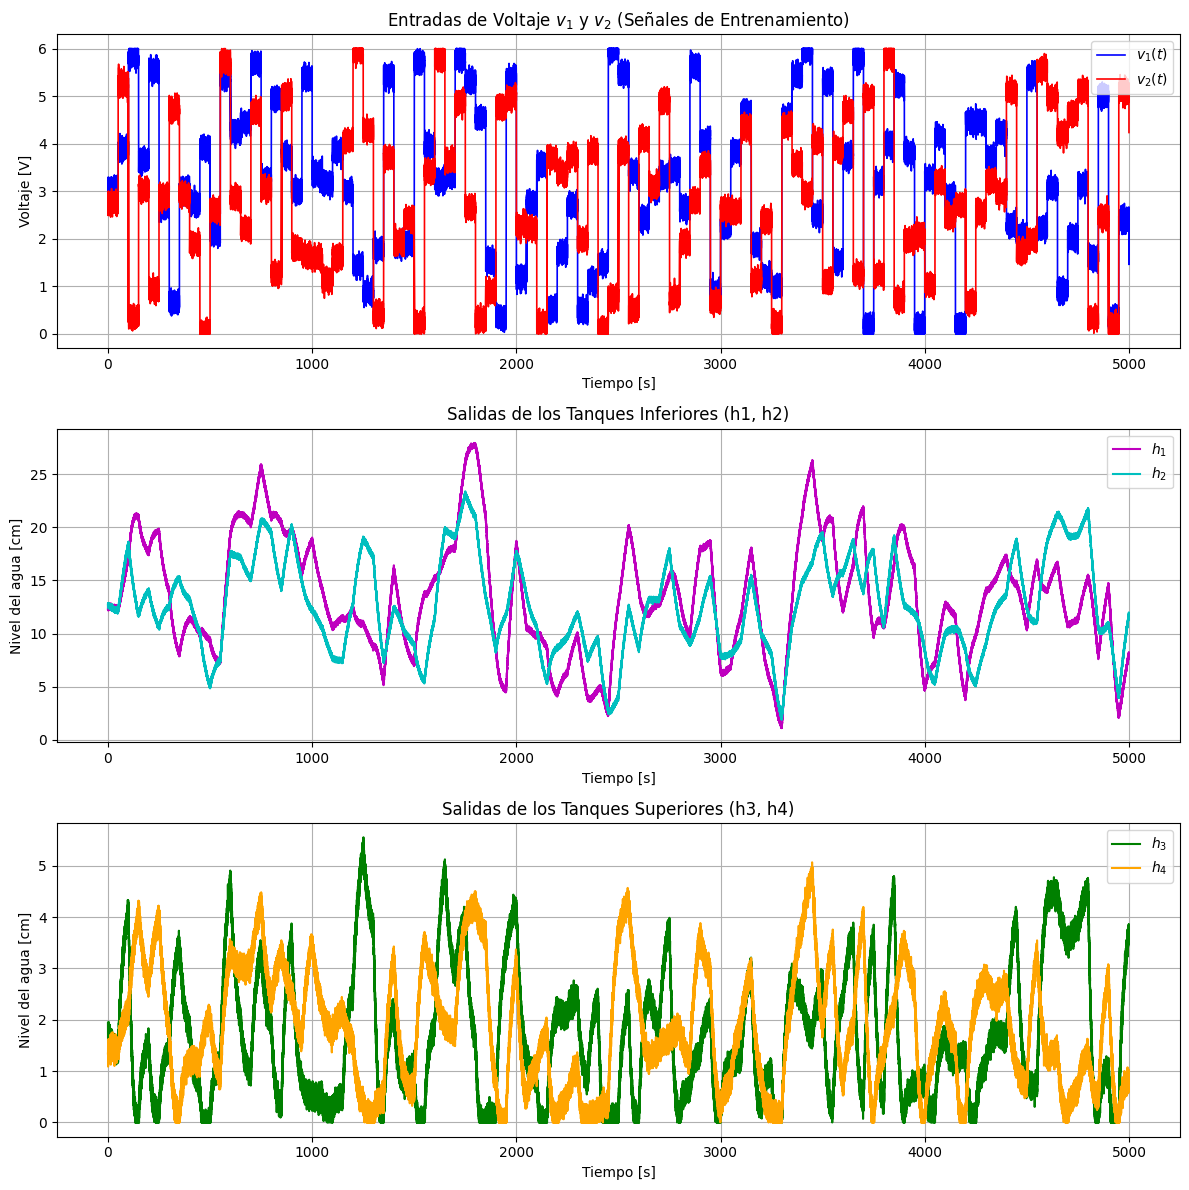

In [9]:
# Figura para visualizar las señales de entrada y salida del sistema.
plt.figure(figsize=(12, 12))

# Subgráfica 1: Señales de entrada de control (Voltajes de las bombas v1 y v2)
plt.subplot(3, 1, 1)
plt.plot(t_full, u_full[:, 0], 'b', linewidth=1.2, label='$v_1(t)$')
plt.plot(t_full, u_full[:, 1], 'r', linewidth=1.2, label='$v_2(t)$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [V]')
plt.title('Entradas de Voltaje $v_1$ y $v_2$ (Señales de Entrenamiento)')
plt.legend(loc='upper right')
plt.grid(True)

# Subgráfica 2: Niveles de los tanques inferiores (h1 y h2)
plt.subplot(3, 1, 2)
plt.plot(t_full, h1_full, 'm', linewidth=1.5, label='$h_1$')
plt.plot(t_full, h2_full, 'c', linewidth=1.5, label='$h_2$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel del agua [cm]')
plt.title('Salidas de los Tanques Inferiores (h1, h2)')
plt.legend(loc='upper right')
plt.grid(True)

# Subgráfica 3: Niveles de los tanques superiores (h3 y h4)
plt.subplot(3, 1, 3)
plt.plot(t_full, h3_full, 'g', linewidth=1.5, label='$h_3$')
plt.plot(t_full, h4_full, 'orange', linewidth=1.5, label='$h_4$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel del agua [cm]')
plt.title('Salidas de los Tanques Superiores (h3, h4)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
def kalman_filter(z, Q=1e-5, R=1e-2):
    n = len(z)
    x_hat = np.zeros(n)      # Estimación del nivel
    P = np.zeros(n)          # Covarianza del error
    x_hat[0] = z[0]
    P[0] = 1.0

    for k in range(1, n):
        # Predicción
        x_hat_minus = x_hat[k-1]
        P_minus = P[k-1] + Q
        # Actualización
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (z[k] - x_hat_minus)
        P[k] = (1 - K) * P_minus
    return x_hat

# Aplicación con parámetros de sintonía (Q: proceso, R: sensor)
h1_full = kalman_filter(h1_full)
h2_full = kalman_filter(h2_full)
h3_full = kalman_filter(h3_full)
h4_full = kalman_filter(h4_full)
u_full[:,0] = kalman_filter(u_full[:,0])
u_full[:,1] = kalman_filter(u_full[:,1])

## Preprocesamiento, normalización y división de datos

In [11]:
# 1. Entradas: Usamos los datos originales (sin suavizar)
# h1_full, h2_full, etc., deben ser tus vectores de datos crudos
X_train = np.hstack([
    h1_full[:-1, None],
    h2_full[:-1, None],
    h3_full[:-1, None],
    h4_full[:-1, None],
    u_full[:-1, :]
])

# 2. Salidas: Estado siguiente original
Y_train = np.hstack([
    h1_full[1:, None],
    h2_full[1:, None],
    h3_full[1:, None],
    h4_full[1:, None]
])

## Arquitectura de red neuronal para entrenamiento

In [12]:
# Dimensiones del sistema MIMO

INPUT_SIZE = 6   # [h1(k), h2(k), h3(k), h4(k), v1(k), v2(k)]
OUTPUT_SIZE = 4  # [h1(k+1), h2(k+1), h3(k+1), h4(k+1)]
HIDDEN_LAYERS = 4
HIDDEN_NEURONS = 48

class PINN_StateSpace_SiLU(nn.Module):
    def __init__(self, input_size, output_size, num_layers, num_neurons):
        super(PINN_StateSpace_SiLU, self).__init__()

        layers = []

        # Capa de entrada: Procesa estados y controles simultáneamente
        layers.append(nn.Linear(input_size, num_neurons))
        layers.append(nn.SiLU())

        # Capas ocultas: Capturan el acoplamiento entre los 4 tanques
        for _ in range(num_layers):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(nn.SiLU())

        # Capa de salida: Predicción de los 4 estados en k+1
        layers.append(nn.Linear(num_neurons, output_size))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Determinar el dispositivo de cómputo (GPU o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instancia del modelo adaptado al sistema de 4 tanques
model = PINN_StateSpace_SiLU(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_LAYERS, HIDDEN_NEURONS).to(device)

print(f"Modelo PINN MIMO (4 Tanques) creado. Entradas: {INPUT_SIZE}, Salidas: {OUTPUT_SIZE}")
print(f"Dispositivo actual: {device}")

Modelo PINN MIMO (4 Tanques) creado. Entradas: 6, Salidas: 4
Dispositivo actual: cuda


## Funciones de normalización y denormalización

In [13]:
#Normalización Min-Max
def normalize_data(data, data_min, data_max):
    denom = data_max - data_min
    if denom == 0:
        return data
    return (data - data_min) / denom

#Denormalización inversa
def denormalize_data(data_norm, data_min, data_max):
    return data_norm * (data_max - data_min) + data_min

## Parámetros de escala para entrenamiento

In [14]:
# Estructura de diccionario para almacenar los límites Min/Max de cada variable.
SCALING_PARAMS = {}

# Parámetros para Entradas de Control (u_full contiene v1 y v2)
v1_min, v1_max = X_train[:, 4].min(), X_train[:, 4].max()
v2_min, v2_max = X_train[:, 5].min(), X_train[:, 5].max()

SCALING_PARAMS['v1'] = {'min': v1_min, 'max': v1_max}
SCALING_PARAMS['v2'] = {'min': v2_min, 'max': v2_max}

# Tanque 1
h1_min = min(X_train[:, 0].min(), Y_train[:, 0].min())
h1_max = max(X_train[:, 0].max(), Y_train[:, 0].max())
SCALING_PARAMS['h1'] = {'min': h1_min, 'max': h1_max}

# Tanque 2
h2_min = min(X_train[:, 1].min(), Y_train[:, 1].min())
h2_max = max(X_train[:, 1].max(), Y_train[:, 1].max())
SCALING_PARAMS['h2'] = {'min': h2_min, 'max': h2_max}

# Tanque 3
h3_min = min(X_train[:, 2].min(), Y_train[:, 2].min())
h3_max = max(X_train[:, 2].max(), Y_train[:, 2].max())
SCALING_PARAMS['h3'] = {'min': h3_min, 'max': h3_max}

# Tanque 4
h4_min = min(X_train[:, 3].min(), Y_train[:, 3].min())
h4_max = max(X_train[:, 3].max(), Y_train[:, 3].max())
SCALING_PARAMS['h4'] = {'min': h4_min, 'max': h4_max}

print("Parámetros de escala definidos para el modelo MIMO [h1, h2, h3, h4, v1, v2].")

Parámetros de escala definidos para el modelo MIMO [h1, h2, h3, h4, v1, v2].


## Normalización de datos de entrada y salida para entrenamiento

In [15]:
# Descomposición de X_train (Entradas: h1_k, h2_k, h3_k, h4_k, v1_k, v2_k)
h1_k = X_train[:, 0]
h2_k = X_train[:, 1]
h3_k = X_train[:, 2]
h4_k = X_train[:, 3]
v1_k = X_train[:, 4]
v2_k = X_train[:, 5]

# Descomposición de Y_train (Salidas: h1_k+1, h2_k+1, h3_k+1, h4_k+1)
h1_next = Y_train[:, 0]
h2_next = Y_train[:, 1]
h3_next = Y_train[:, 2]
h4_next = Y_train[:, 3]

# Aplicación de normalización Min-Max a cada variable de entrada
h1_k_norm = normalize_data(h1_k, SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_k_norm = normalize_data(h2_k, SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_k_norm = normalize_data(h3_k, SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_k_norm = normalize_data(h4_k, SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])
v1_k_norm = normalize_data(v1_k, SCALING_PARAMS['v1']['min'], SCALING_PARAMS['v1']['max'])
v2_k_norm = normalize_data(v2_k, SCALING_PARAMS['v2']['min'], SCALING_PARAMS['v2']['max'])

# Aplicación de normalización Min-Max a cada variable de salida (k+1)
h1_next_norm = normalize_data(h1_next, SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_next_norm = normalize_data(h2_next, SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_next_norm = normalize_data(h3_next, SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_next_norm = normalize_data(h4_next, SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])

# Reensamblar los conjuntos de datos normalizados para el entrenamiento
X_train_norm = np.hstack([
    h1_k_norm[:, None],
    h2_k_norm[:, None],
    h3_k_norm[:, None],
    h4_k_norm[:, None],
    v1_k_norm[:, None],
    v2_k_norm[:, None]
])

Y_train_norm = np.hstack([
    h1_next_norm[:, None],
    h2_next_norm[:, None],
    h3_next_norm[:, None],
    h4_next_norm[:, None]
])

print("Normalización aplicada exitosamente a la estructura MIMO de 4 tanques.")
print(f"Dimensiones finales: X_train_norm {X_train_norm.shape}, Y_train_norm {Y_train_norm.shape}")

Normalización aplicada exitosamente a la estructura MIMO de 4 tanques.
Dimensiones finales: X_train_norm (100000, 6), Y_train_norm (100000, 4)


## Tensores de entrenamiento

In [16]:
# Tensores de Entrenamiento (Observaciones para Loss de Datos)
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train_norm, dtype=torch.float32).to(device)


''' En el modelo de espacio de estados, se usa los mismos puntos de entrada
para evaluar la pérdida física (residual de la EDO). requires_grad_(True) es
vital para que la PINN pueda derivar respecto a los estados de entrada.'''

X_physics_tensor = X_train_tensor.clone().detach().requires_grad_(True)

print(f"\nConversión a tensores de PyTorch completada en el dispositivo: {device}")
print(f"X_train_tensor.shape (Data Loss - MIMO 6): {X_train_tensor.shape}")
print(f"Y_train_tensor.shape (Data Loss - MIMO 4): {Y_train_tensor.shape}")
print(f"X_physics_tensor.shape (Physics Loss - MIMO 6): {X_physics_tensor.shape}")


Conversión a tensores de PyTorch completada en el dispositivo: cuda
X_train_tensor.shape (Data Loss - MIMO 6): torch.Size([100000, 6])
Y_train_tensor.shape (Data Loss - MIMO 4): torch.Size([100000, 4])
X_physics_tensor.shape (Physics Loss - MIMO 6): torch.Size([100000, 6])


## Función de pérdida física para la red neuronal informada por físicas

In [17]:
class PhysicsLoss(nn.Module):
    def __init__(self, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2, epsilon, dt, SCALING_PARAMS):
        '''Cálculo de residuales para el sistema de 4 tanques: transición k -> k+1'''
        super(PhysicsLoss, self).__init__()

        # Almacenar constantes físicas como tensores
        self.A1, self.A2 = torch.tensor(A1).to(device), torch.tensor(A2).to(device)
        self.A3, self.A4 = torch.tensor(A3).to(device), torch.tensor(A4).to(device)
        self.a1, self.a2 = torch.tensor(a1).to(device), torch.tensor(a2).to(device)
        self.a3, self.a4 = torch.tensor(a3).to(device), torch.tensor(a4).to(device)
        self.g = torch.tensor(g).to(device)
        self.k1, self.k2 = torch.tensor(k1).to(device), torch.tensor(k2).to(device)
        self.gamma1 = torch.tensor(gamma1).to(device)
        self.gamma2 = torch.tensor(gamma2).to(device)

        self.epsilon = torch.tensor(epsilon, dtype=torch.float32).to(device)
        self.dt = torch.tensor(dt, dtype=torch.float32).to(device)

        # Parámetros de denormalización (4 tanques + 2 bombas)
        self.h1_min, self.h1_max = torch.tensor(SCALING_PARAMS['h1']['min']).to(device), torch.tensor(SCALING_PARAMS['h1']['max']).to(device)
        self.h2_min, self.h2_max = torch.tensor(SCALING_PARAMS['h2']['min']).to(device), torch.tensor(SCALING_PARAMS['h2']['max']).to(device)
        self.h3_min, self.h3_max = torch.tensor(SCALING_PARAMS['h3']['min']).to(device), torch.tensor(SCALING_PARAMS['h3']['max']).to(device)
        self.h4_min, self.h4_max = torch.tensor(SCALING_PARAMS['h4']['min']).to(device), torch.tensor(SCALING_PARAMS['h4']['max']).to(device)
        self.v1_min, self.v1_max = torch.tensor(SCALING_PARAMS['v1']['min']).to(device), torch.tensor(SCALING_PARAMS['v1']['max']).to(device)
        self.v2_min, self.v2_max = torch.tensor(SCALING_PARAMS['v2']['min']).to(device), torch.tensor(SCALING_PARAMS['v2']['max']).to(device)

    def forward(self, x_norm, h_next_pred_norm):
        # x_norm: [h1_k_norm, h2_k_norm, h3_k_norm, h4_k_norm, v1_k_norm, v2_k_norm]
        # h_next_pred_norm: [h1_k+1_norm, h2_k+1_norm, h3_k+1_norm, h4_k+1_norm]

        # 1. Denormalización del estado actual k (Entradas)
        h1_k = self.h1_min + x_norm[:, 0:1] * (self.h1_max - self.h1_min)
        h2_k = self.h2_min + x_norm[:, 1:2] * (self.h2_max - self.h2_min)
        h3_k = self.h3_min + x_norm[:, 2:3] * (self.h3_max - self.h3_min)
        h4_k = self.h4_min + x_norm[:, 3:4] * (self.h4_max - self.h4_min)
        v1_k = self.v1_min + x_norm[:, 4:5] * (self.v1_max - self.v1_min)
        v2_k = self.v2_min + x_norm[:, 5:6] * (self.v2_max - self.v2_min)

        # 2. Denormalización del estado predicho k+1 (Salidas de la red)
        h1_k1_pred = self.h1_min + h_next_pred_norm[:, 0:1] * (self.h1_max - self.h1_min)
        h2_k1_pred = self.h2_min + h_next_pred_norm[:, 1:2] * (self.h2_max - self.h2_min)
        h3_k1_pred = self.h3_min + h_next_pred_norm[:, 2:3] * (self.h3_max - self.h3_min)
        h4_k1_pred = self.h4_min + h_next_pred_norm[:, 3:4] * (self.h4_max - self.h4_min)

        # 3. Cálculo de las derivadas físicas instantáneas (Leyes de Torricelli y Balance de Masa)
        h1_s = torch.max(h1_k, self.epsilon)
        h2_s = torch.max(h2_k, self.epsilon)
        h3_s = torch.max(h3_k, self.epsilon)
        h4_s = torch.max(h4_k, self.epsilon)

        dh1_dt = -(self.a1/self.A1)*torch.sqrt(2*self.g*h1_s) + (self.a3/self.A1)*torch.sqrt(2*self.g*h3_s) + (self.gamma1*self.k1/self.A1)*v1_k
        dh2_dt = -(self.a2/self.A2)*torch.sqrt(2*self.g*h2_s) + (self.a4/self.A2)*torch.sqrt(2*self.g*h4_s) + (self.gamma2*self.k2/self.A2)*v2_k
        dh3_dt = -(self.a3/self.A3)*torch.sqrt(2*self.g*h3_s) + ((1-self.gamma2)*self.k2/self.A3)*v2_k
        dh4_dt = -(self.a4/self.A4)*torch.sqrt(2*self.g*h4_s) + ((1-self.gamma1)*self.k1/self.A4)*v1_k

        # 4. Cálculo de los residuales basados en Euler
        R1 = h1_k1_pred - (h1_k + self.dt * dh1_dt)
        R2 = h2_k1_pred - (h2_k + self.dt * dh2_dt)
        R3 = h3_k1_pred - (h3_k + self.dt * dh3_dt)
        R4 = h4_k1_pred - (h4_k + self.dt * dh4_dt)

        return R1, R2, R3, R4

## Función de cálculo total de la pérdida de la red neuronal

In [18]:
def calculate_total_loss(model, physics_loss_module, X_train, Y_train, X_res, w_data=1.0, w_res=200.0, w_ic=10.0):
    # 1. Pérdida de los datos (Supervisada - Mean Squared Error)
    h_pred_data = model(X_train)
    loss_data = torch.mean((h_pred_data - Y_train) ** 2)

    # 2. Pérdida residual (Física / PINN)
    h_pred_res = model(X_res)

    # Residuales del sistema MIMO
    R1, R2, R3, R4 = physics_loss_module(X_res, h_pred_res)

    # Sumatoria de los residuales físicos al cuadrado
    loss_res = torch.mean(R1 ** 2) + torch.mean(R2 ** 2) + \
               torch.mean(R3 ** 2) + torch.mean(R4 ** 2)

    # 3. Pérdida de condiciones iniciales (IC)
    X_ic = X_train[0:1]
    h_pred_ic = model(X_ic)
    Y_ic_target = Y_train[0:1]
    loss_ic = torch.mean((h_pred_ic - Y_ic_target) ** 2)

    # 4. Pérdida total ponderada
    total_loss = w_data * loss_data + w_res * loss_res + w_ic * loss_ic

    return total_loss, loss_data, loss_res, loss_ic

## Inicialización de pérdida física e historial de entrenamiento

In [19]:
# Parámetro de estabilidad para evitar gradientes infinitos en sqrt(h)
epsilon = 1e-6

# Mover el modelo de red neuronal al dispositivo de cómputo (GPU/CPU)
model.to(device)

# Inicializar el módulo de pérdida física con los parámetros del sistema MIMO
physics_loss_module = PhysicsLoss(
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2,
    gamma1, gamma2,
    epsilon, dt, SCALING_PARAMS
).to(device)

# Listas de historial para monitorear la convergencia del entrenamiento
loss_history = []
loss_data_history = []
loss_res_history = []
loss_ic_history = []

print("Módulo de pérdida física configurado para el sistema de 4 tanques.")

Módulo de pérdida física configurado para el sistema de 4 tanques.


## Primera fase de entrenamiento con optimizador Adam

In [20]:
# Definición de los pesos para la función de pérdida
W_DATA = 1.0
W_RES = 100.0
W_IC = 10.0

LEARNING_RATE_ADAM = 1e-3
NUM_EPOCHS_ADAM = 4000
optimizer_adam = optim.Adam(model.parameters(), lr=LEARNING_RATE_ADAM)

print(f"--- FASE 1: Iniciando entrenamiento con Adam ({NUM_EPOCHS_ADAM} épocas) ---")
print(f"Entrenando para un sistema de 4 estados y 2 entradas...")

for epoch in range(1, NUM_EPOCHS_ADAM + 1):
    model.train()
    optimizer_adam.zero_grad()

    # Cálculo de la pérdida total utilizando el módulo adaptado a 4 tanques
    # X_train_tensor: [h1_k, h2_k, h3_k, h4_k, v1_k, v2_k]
    # Y_train_tensor: [h1_k+1, h2_k+1, h3_k+1, h4_k+1]
    total_loss, loss_data, loss_res, loss_ic = calculate_total_loss(
        model,
        physics_loss_module,
        X_train_tensor,
        Y_train_tensor,
        X_physics_tensor,
        w_data=W_DATA,
        w_res=W_RES,
        w_ic=W_IC
    )

    # Retropropagación
    total_loss.backward()
    optimizer_adam.step()

    # Monitoreo y almacenamiento de historial cada 250 épocas
    if epoch % 250 == 0:
        loss_history.append(total_loss.item())
        loss_data_history.append(loss_data.item())
        loss_res_history.append(loss_res.item())
        loss_ic_history.append(loss_ic.item())

        # Impresión de progreso: L_D (Pérdida Datos), L_R (Pérdida Residual Física)
        print(f"Adam Época: {epoch}/{NUM_EPOCHS_ADAM} | Total Loss: {total_loss.item():.6e} | L_D: {loss_data.item():.6e} | L_R: {loss_res.item():.6e}")

print("--- FASE 1 COMPLETADA ---")
print(f"Pérdida final de Adam: {total_loss.item():.6e}")

--- FASE 1: Iniciando entrenamiento con Adam (4000 épocas) ---
Entrenando para un sistema de 4 estados y 2 entradas...
Adam Época: 250/4000 | Total Loss: 1.484284e+02 | L_D: 9.450761e-03 | L_R: 1.484116e+00
Adam Época: 500/4000 | Total Loss: 6.318785e+01 | L_D: 4.864153e-03 | L_R: 6.318040e-01
Adam Época: 750/4000 | Total Loss: 6.047287e+01 | L_D: 4.788770e-03 | L_R: 6.046553e-01
Adam Época: 1000/4000 | Total Loss: 5.592543e+01 | L_D: 4.504991e-03 | L_R: 5.591851e-01
Adam Época: 1250/4000 | Total Loss: 1.563424e+01 | L_D: 9.981081e-04 | L_R: 1.563151e-01
Adam Época: 1500/4000 | Total Loss: 5.996801e+00 | L_D: 2.885014e-04 | L_R: 5.994944e-02
Adam Época: 1750/4000 | Total Loss: 3.513058e+00 | L_D: 1.717648e-04 | L_R: 3.511453e-02
Adam Época: 2000/4000 | Total Loss: 2.440679e+00 | L_D: 1.536746e-04 | L_R: 2.438826e-02
Adam Época: 2250/4000 | Total Loss: 2.030025e+00 | L_D: 1.537648e-04 | L_R: 2.027931e-02
Adam Época: 2500/4000 | Total Loss: 1.840045e+00 | L_D: 1.524869e-04 | L_R: 1.83784

## Segunda fase de entrenamiento con optimizador L-BFGS

In [21]:
# Configuración del optimizador L-BFGS
optimizer_lbfgs = optim.LBFGS(
    model.parameters(),
    lr=0.5,
    max_iter=4000,
    max_eval=4000,
    history_size=50,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe" # Búsqueda de línea para garantizar descenso
)

lbfgs_eval_count = 0
current_lbfgs_loss = 0.0

def closure():
    global lbfgs_eval_count, current_lbfgs_loss
    lbfgs_eval_count += 1
    optimizer_lbfgs.zero_grad()

    # Cálculo de pérdida con la estructura MIMO de 4 tanques
    # X_train_tensor: Datos observados [h1...h4, v1, v2]
    # X_physics_tensor: Puntos para validar las 4 ecuaciones diferenciales
    total_loss, loss_data, loss_res, loss_ic = calculate_total_loss(
        model,
        physics_loss_module,
        X_train_tensor,
        Y_train_tensor,
        X_physics_tensor,
        w_data=W_DATA,
        w_res=W_RES,
        w_ic=W_IC
    )

    # Retropropagación
    total_loss.backward()

    # Monitoreo de la pérdida actual
    current_lbfgs_loss = total_loss.item()

    if lbfgs_eval_count % 100 == 0:
        print(f"L-BFGS Evaluación: {lbfgs_eval_count} | Loss: {total_loss.item():.6e} | Res: {loss_res.item():.6e}")

    return total_loss

print("\n--- FASE 2: Iniciando ajuste fino con L-BFGS-B (Alta Precisión) ---")
print("Este proceso busca el mínimo global de los 4 residuales físicos...")
optimizer_lbfgs.step(closure)

print("\n--- FASE 2 COMPLETADA ---")
print(f"L-BFGS ha finalizado el ajuste. Pérdida final consolidada: {current_lbfgs_loss:.6e}")


--- FASE 2: Iniciando ajuste fino con L-BFGS-B (Alta Precisión) ---
Este proceso busca el mínimo global de los 4 residuales físicos...
L-BFGS Evaluación: 100 | Loss: 1.083408e+00 | Res: 1.081511e-02
L-BFGS Evaluación: 200 | Loss: 7.648868e-01 | Res: 7.641202e-03
L-BFGS Evaluación: 300 | Loss: 3.121435e-01 | Res: 3.117435e-03
L-BFGS Evaluación: 400 | Loss: 1.718881e-01 | Res: 1.714904e-03
L-BFGS Evaluación: 500 | Loss: 1.046003e-01 | Res: 1.042145e-03
L-BFGS Evaluación: 600 | Loss: 5.863704e-02 | Res: 5.832451e-04
L-BFGS Evaluación: 700 | Loss: 4.219621e-02 | Res: 4.188790e-04
L-BFGS Evaluación: 800 | Loss: 3.154666e-02 | Res: 3.118647e-04
L-BFGS Evaluación: 900 | Loss: 2.633645e-02 | Res: 2.599901e-04
L-BFGS Evaluación: 1000 | Loss: 2.253870e-02 | Res: 2.221728e-04
L-BFGS Evaluación: 1100 | Loss: 1.998824e-02 | Res: 1.965890e-04
L-BFGS Evaluación: 1200 | Loss: 1.740108e-02 | Res: 1.705765e-04
L-BFGS Evaluación: 1300 | Loss: 1.569704e-02 | Res: 1.535959e-04
L-BFGS Evaluación: 1400 | Lo

## Denormalización de predicción y datos reales después de entrenamiento

In [22]:
# Evaluación del modelo
model.eval()

with torch.no_grad():

    '''La red predice el vector de estados k+1: [h1, h2, h3, h4] a
    partir de X_train_tensor: [h1_k, h2_k, h3_k, h4_k, v1_k, v2_k]'''

    h_pred_train_norm = model(X_train_tensor).cpu().numpy()

# Denormalización de las 4 predicciones del modelo (Salidas k+1)
h1_pred_train = denormalize_data(h_pred_train_norm[:, 0], SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_pred_train = denormalize_data(h_pred_train_norm[:, 1], SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_pred_train = denormalize_data(h_pred_train_norm[:, 2], SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_pred_train = denormalize_data(h_pred_train_norm[:, 3], SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])

# Denormalización de los datos reales (Targets k+1 para comparación)
Y_train_real_norm = Y_train_tensor.cpu().numpy()
h1_train_real = denormalize_data(Y_train_real_norm[:, 0], SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_train_real = denormalize_data(Y_train_real_norm[:, 1], SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_train_real = denormalize_data(Y_train_real_norm[:, 2], SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_train_real = denormalize_data(Y_train_real_norm[:, 3], SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])

# Vector de tiempo para la validación (k+1)
t_plot = t_full[1:]

print("Predicciones denormalizadas para los 4 tanques.")

Predicciones denormalizadas para los 4 tanques.


## Visualización de tanques 1 y 2: Red neuronal informada por físicas vs Simulación

In [23]:
# --- EVALUACIÓN DE DESEMPEÑO DE LA PINN: MÉTRICAS POR TANQUE ---

def calculate_metrics(real, pred):
    # Root Mean Square Error (RMSE): Magnitud del error cuadrático medio
    rmse = np.sqrt(np.mean((real - pred)**2))

    # Mean Absolute Error (MAE): Promedio del error absoluto físico
    mae = np.mean(np.abs(real - pred))

    # Variance Actually Fraction (VAF): Precisión en la captura de la dinámica (%)
    vaf = max(0, (1 - np.var(real - pred) / np.var(real)) * 100)

    return rmse, mae, vaf

# Cálculo de métricas para cada estado predicho por la PINN
rmse1, mae1, vaf1 = calculate_metrics(h1_train_real, h1_pred_train)
rmse2, mae2, vaf2 = calculate_metrics(h2_train_real, h2_pred_train)
rmse3, mae3, vaf3 = calculate_metrics(h3_train_real, h3_pred_train)
rmse4, mae4, vaf4 = calculate_metrics(h4_train_real, h4_pred_train)

# --- REPORTE DE PRECISIÓN DE LA RED NEURONAL ---
print("\n" + "="*60)
print(f"{'TANQUE':<12} | {'RMSE [cm]':<12} | {'MAE [cm]':<12} | {'VAF [%]':<10}")
print("-" * 60)
print(f"{'Tanque 1 (h1)':<12} | {rmse1:9.4f}    | {mae1:9.4f}    | {vaf1:7.2f}%")
print(f"{'Tanque 2 (h2)':<12} | {rmse2:9.4f}    | {mae2:9.4f}    | {vaf2:7.2f}%")
print(f"{'Tanque 3 (h3)':<12} | {rmse3:9.4f}    | {mae3:9.4f}    | {vaf3:7.2f}%")
print(f"{'Tanque 4 (h4)':<12} | {rmse4:9.4f}    | {mae4:9.4f}    | {vaf4:7.2f}%")
print("="*60 + "\n")


TANQUE       | RMSE [cm]    | MAE [cm]     | VAF [%]   
------------------------------------------------------------
Tanque 1 (h1) |    0.0039    |    0.0031    |  100.00%
Tanque 2 (h2) |    0.0039    |    0.0031    |  100.00%
Tanque 3 (h3) |    0.0035    |    0.0028    |  100.00%
Tanque 4 (h4) |    0.0039    |    0.0031    |  100.00%



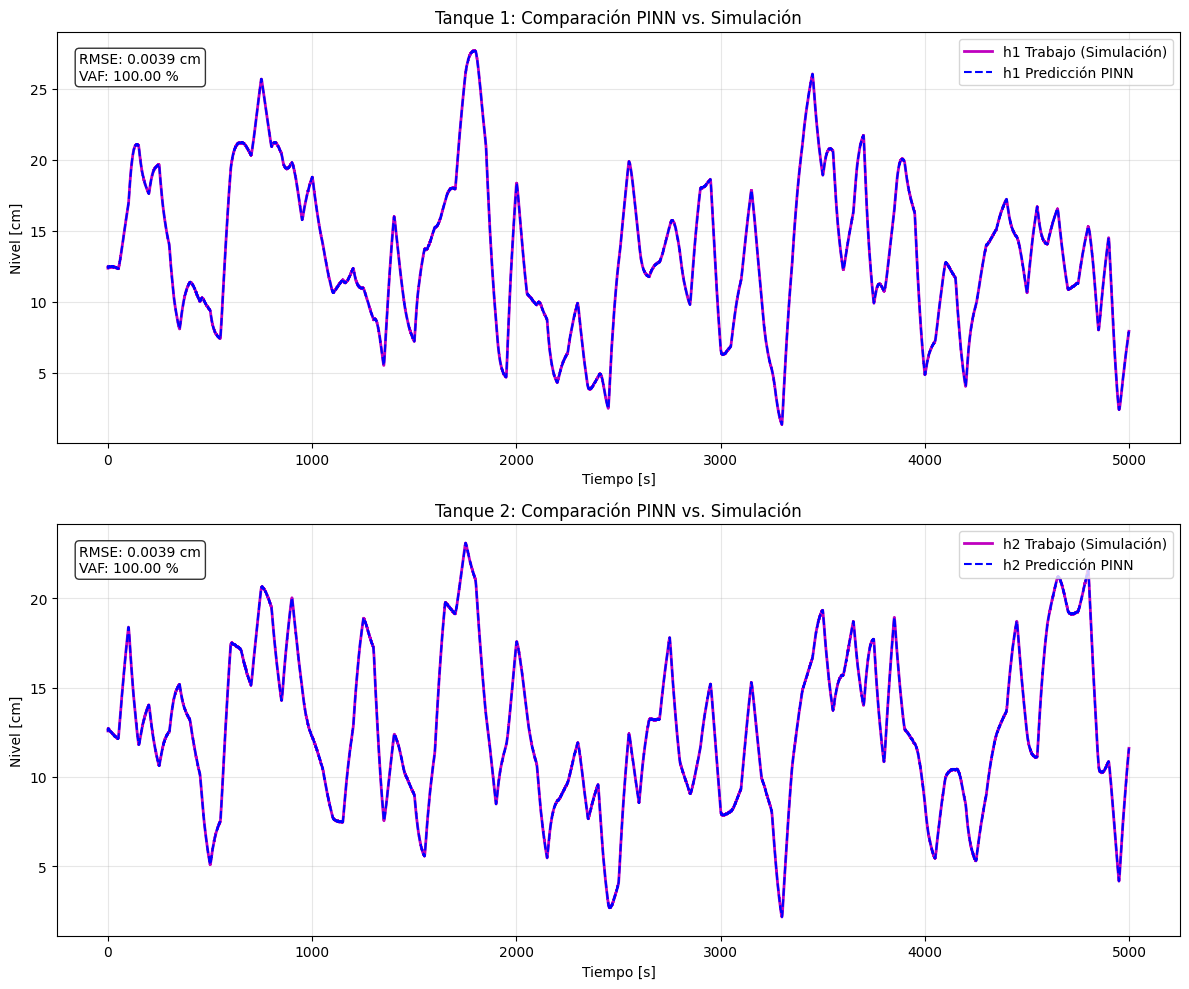

Métricas Finales:
Tanque 1 -> RMSE: 0.0039, VAF: 100.00%
Tanque 2 -> RMSE: 0.0039, VAF: 100.00%


In [24]:
# Figura de visualización
plt.figure(figsize=(12, 10))

# Altura h1 (Tanque Inferior 1)
plt.subplot(2, 1, 1)
plt.plot(t_plot, h1_train_real, 'm', linewidth=2, label='h1 Trabajo (Simulación)')
plt.plot(t_plot, h1_pred_train, 'b--', linewidth=1.5, label='h1 Predicción PINN')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel [cm]')
plt.title('Tanque 1: Comparación PINN vs. Simulación')
# Añadir métricas en el gráfico
textstr1 = '\n'.join((f'RMSE: {rmse1:.4f} cm', f'VAF: {vaf1:.2f} %'))
plt.gca().text(0.02, 0.95, textstr1, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Altura h2 (Tanque Inferior 2)
plt.subplot(2, 1, 2)
plt.plot(t_plot, h2_train_real, 'm', linewidth=2, label='h2 Trabajo (Simulación)')
plt.plot(t_plot, h2_pred_train, 'b--', linewidth=1.5, label='h2 Predicción PINN')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel [cm]')
plt.title('Tanque 2: Comparación PINN vs. Simulación')

# Añadir métricas en el gráfico
textstr2 = '\n'.join((f'RMSE: {rmse2:.4f} cm', f'VAF: {vaf2:.2f} %'))
plt.gca().text(0.02, 0.95, textstr2, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Métricas Finales:\nTanque 1 -> RMSE: {rmse1:.4f}, VAF: {vaf1:.2f}%")
print(f"Tanque 2 -> RMSE: {rmse2:.4f}, VAF: {vaf2:.2f}%")

In [25]:
import pandas as pd

# Estructuración de los datos de los tanques inferiores (Resultados PINN)
data_pinn_inferiores = {
    'Tiempo [s]': t_plot.flatten(),
    'h1_Real [cm]': h1_train_real.flatten(),
    'h1_PINN [cm]': h1_pred_train.flatten(),
    'h2_Real [cm]': h2_train_real.flatten(),
    'h2_PINN [cm]': h2_pred_train.flatten()
}

# Creación del DataFrame
df_pinn = pd.DataFrame(data_pinn_inferiores)

# Exportación a CSV
nombre_pinn_csv = "comparacion_pinn_tanques_inferiores.csv"
df_pinn.to_csv(nombre_pinn_csv, index=False, sep=',', encoding='utf-8')

print(f"✅ Archivo de validación PINN guardado como: {nombre_pinn_csv}")

✅ Archivo de validación PINN guardado como: comparacion_pinn_tanques_inferiores.csv


## Visualización de tanques 3 y 4: Red neuronal informada por físicas vs Simulación

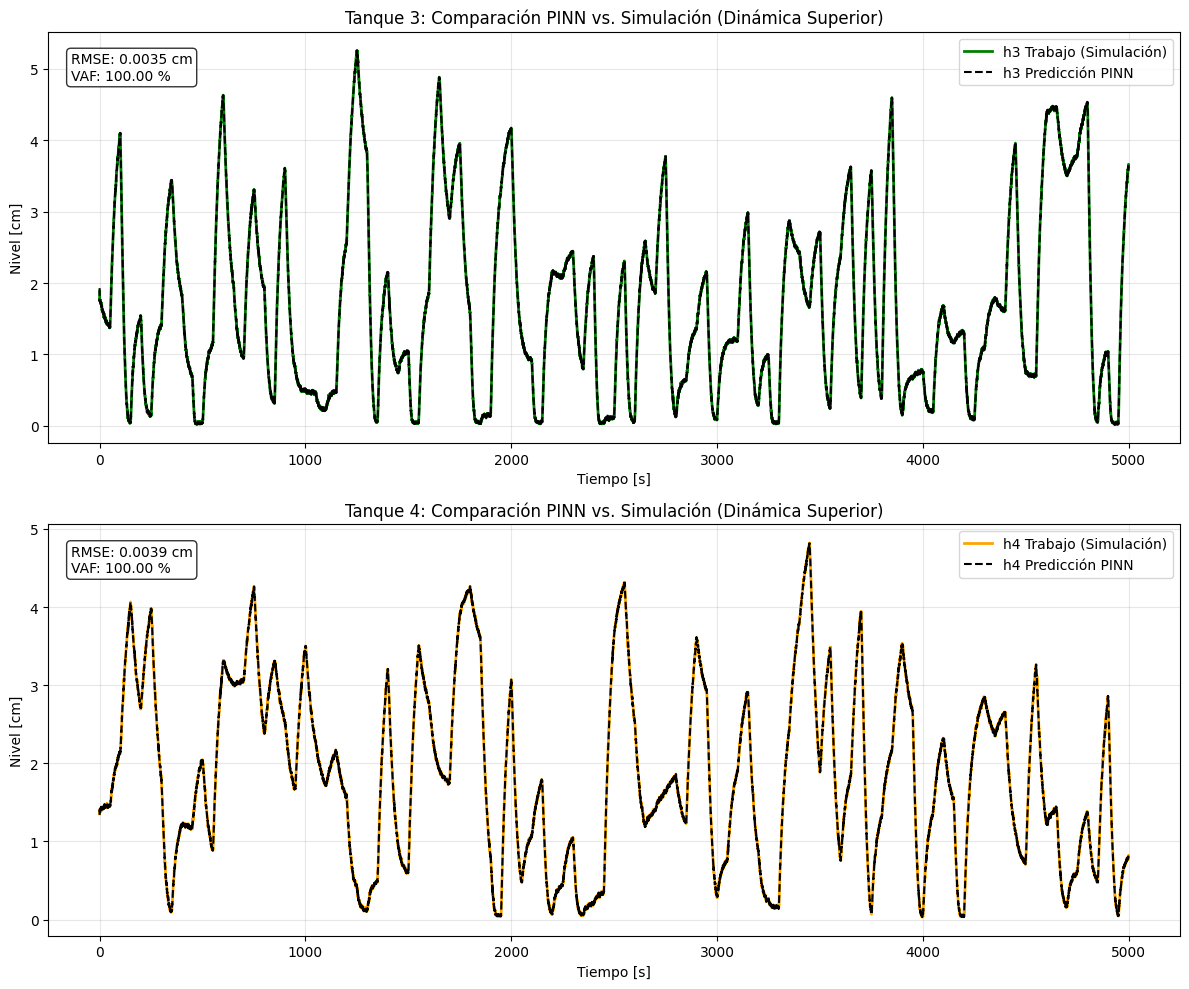

Métricas Finales Superiores:
Tanque 3 -> RMSE: 0.0035, VAF: 100.00%
Tanque 4 -> RMSE: 0.0039, VAF: 100.00%


In [26]:
# Figura de visualización para Tanques Superiores
plt.figure(figsize=(12, 10))

# Altura h3 (Tanque Superior 3)
plt.subplot(2, 1, 1)
plt.plot(t_plot, h3_train_real, 'g', linewidth=2, label='h3 Trabajo (Simulación)')
plt.plot(t_plot, h3_pred_train, 'k--', linewidth=1.5, label='h3 Predicción PINN')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel [cm]')
plt.title('Tanque 3: Comparación PINN vs. Simulación (Dinámica Superior)')

# Añadir métricas h3
textstr3 = '\n'.join((f'RMSE: {rmse3:.4f} cm', f'VAF: {vaf3:.2f} %'))
plt.gca().text(0.02, 0.95, textstr3, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Altura h4 (Tanque Superior 4)
plt.subplot(2, 1, 2)
plt.plot(t_plot, h4_train_real, 'orange', linewidth=2, label='h4 Trabajo (Simulación)')
plt.plot(t_plot, h4_pred_train, 'k--', linewidth=1.5, label='h4 Predicción PINN')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel [cm]')
plt.title('Tanque 4: Comparación PINN vs. Simulación (Dinámica Superior)')

# Añadir métricas h4
textstr4 = '\n'.join((f'RMSE: {rmse4:.4f} cm', f'VAF: {vaf4:.2f} %'))
plt.gca().text(0.02, 0.95, textstr4, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Métricas Finales Superiores:\nTanque 3 -> RMSE: {rmse3:.4f}, VAF: {vaf3:.2f}%")
print(f"Tanque 4 -> RMSE: {rmse4:.4f}, VAF: {vaf4:.2f}%")

In [27]:
import pandas as pd

# Estructuración de los datos de los tanques superiores (Resultados PINN)
data_pinn_superiores = {
    'Tiempo [s]': t_plot.flatten(),
    'h3_Real [cm]': h3_train_real.flatten(),
    'h3_PINN [cm]': h3_pred_train.flatten(),
    'h4_Real [cm]': h4_train_real.flatten(),
    'h4_PINN [cm]': h4_pred_train.flatten()
}

# Creación del DataFrame
df_pinn_sup = pd.DataFrame(data_pinn_superiores)

# Exportación a CSV
nombre_pinn_csv_sup = "comparacion_pinn_tanques_superiores.csv"
df_pinn_sup.to_csv(nombre_pinn_csv_sup, index=False, sep=',', encoding='utf-8')

print(f"✅ Datos de tanques superiores guardados exitosamente en: {nombre_pinn_csv_sup}")

✅ Datos de tanques superiores guardados exitosamente en: comparacion_pinn_tanques_superiores.csv


## Visualización de pérdidas después de entrenamiento

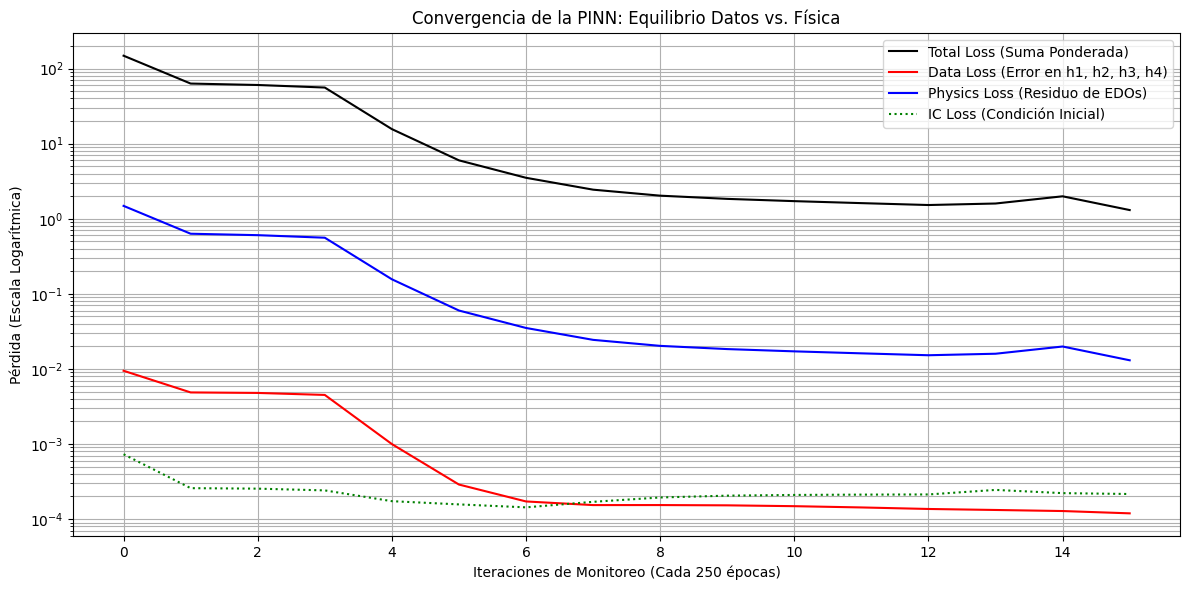

In [28]:
# Figura de visualización de pérdidas
plt.figure(figsize=(12, 6))

plt.semilogy(loss_history, 'k', label='Total Loss (Suma Ponderada)')
plt.semilogy(loss_data_history, 'r', label='Data Loss (Error en h1, h2, h3, h4)')
plt.semilogy(loss_res_history, 'b', label='Physics Loss (Residuo de EDOs)')
plt.semilogy(loss_ic_history, 'g', linestyle=':', label='IC Loss (Condición Inicial)')

plt.xlabel('Iteraciones de Monitoreo (Cada 250 épocas)')
plt.ylabel('Pérdida (Escala Logarítmica)')
plt.title('Convergencia de la PINN: Equilibrio Datos vs. Física')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

## Gráficas de error de los 4 tanques

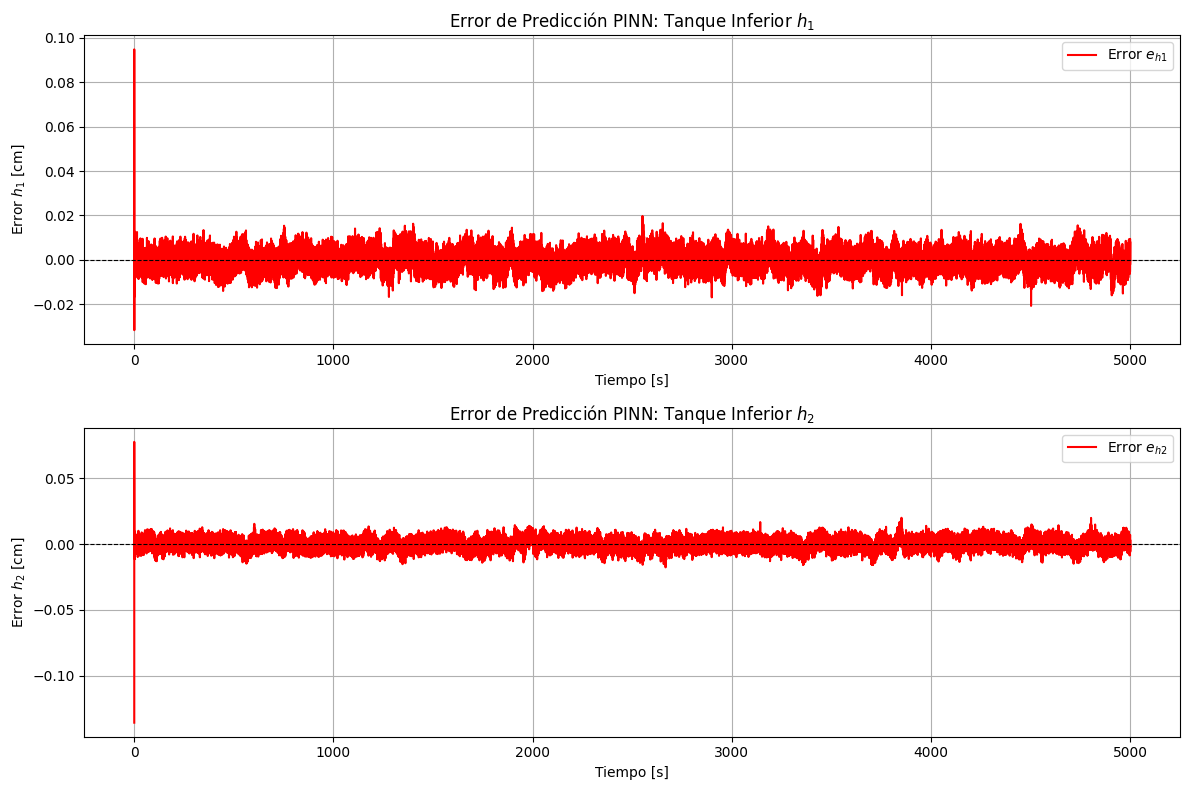

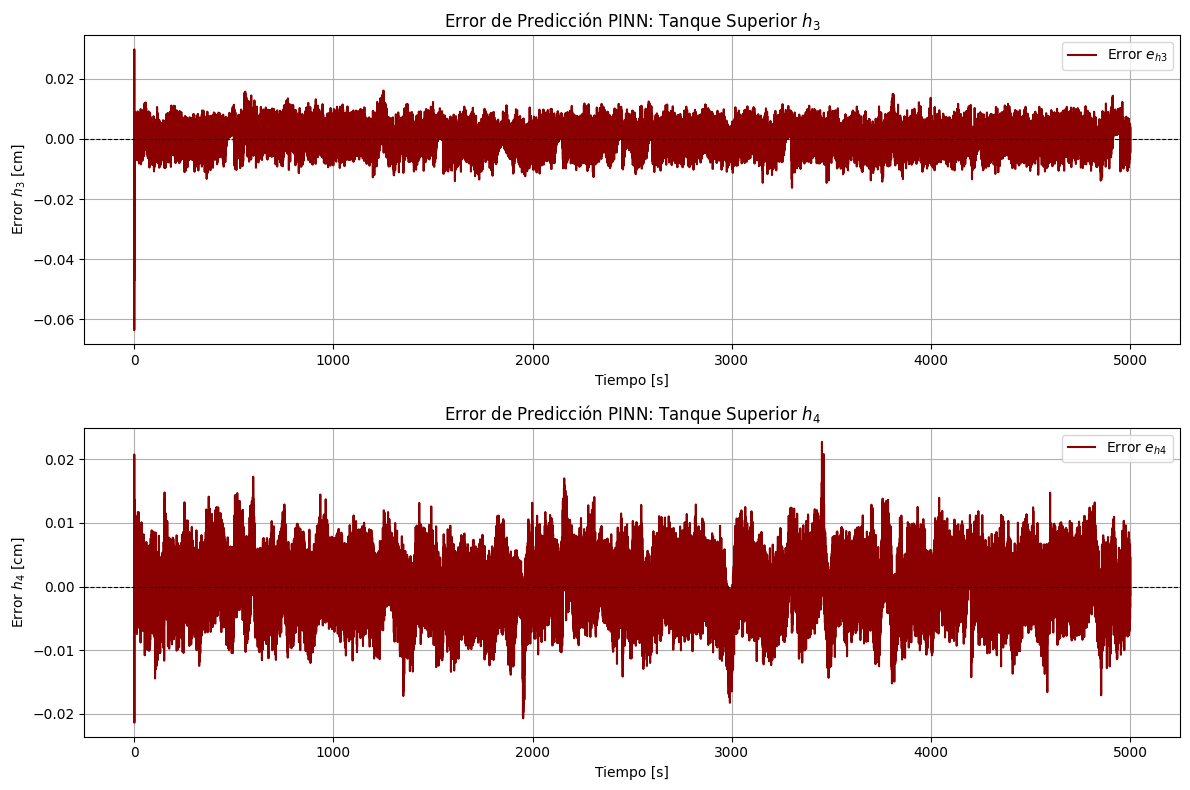

In [29]:
# Cálculo del vector de error para los 4 tanques (Valores en cm)
error_h1_pinn = h1_train_real - h1_pred_train
error_h2_pinn = h2_train_real - h2_pred_train
error_h3_pinn = h3_train_real - h3_pred_train
error_h4_pinn = h4_train_real - h4_pred_train

# Figura de visualización de errores en tanques inferiores
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_plot, error_h1_pinn, 'r', linewidth=1.5, label='Error $e_{h1}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Error $h_1$ [cm]')
plt.title('Error de Predicción PINN: Tanque Inferior $h_1$')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_plot, error_h2_pinn, 'r', linewidth=1.5, label='Error $e_{h2}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Error $h_2$ [cm]')
plt.title('Error de Predicción PINN: Tanque Inferior $h_2$')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Figura de visualización de errores en tanques superiores
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_plot, error_h3_pinn, 'darkred', linewidth=1.5, label='Error $e_{h3}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Error $h_3$ [cm]')
plt.title('Error de Predicción PINN: Tanque Superior $h_3$')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_plot, error_h4_pinn, 'darkred', linewidth=1.5, label='Error $e_{h4}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Error $h_4$ [cm]')
plt.title('Error de Predicción PINN: Tanque Superior $h_4$')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## Métricas de entrenamiento de la red neuronal informada por físicas

In [30]:
# Concatenación de todos los errores (k+1)
error_full = np.concatenate((error_h1_pinn, error_h2_pinn, error_h3_pinn, error_h4_pinn))

MSE = np.mean(error_full**2)
RMSE = np.sqrt(MSE)
MAE = np.mean(np.abs(error_full))
SSE = np.sum(error_full**2)

# Error cuadrático medio normalizado (NRMSE)
h_real_concat = np.concatenate((h1_train_real, h2_train_real, h3_train_real, h4_train_real))
range_h = np.max(h_real_concat) - np.min(h_real_concat)

if range_h != 0:
    NRMSE = RMSE / range_h
else:
    NRMSE = 0.0

print("\n--------------------------- Métricas de Error de Aproximación -------------------------------")
print(f"MSE (Error Cuadrático Medio global)\t\t: {MSE:.8e} m^2 \t|({MSE*10000:.8e} cm^2)")
print(f"RMSE (Raíz del Error Cuadrático Medio global)\t: {RMSE:.8e} m \t|({RMSE*100:.8e} cm)")
print(f"MAE (Error Absoluto Medio global)\t\t: {MAE:.8e} m \t|({MAE*100:.8e} cm)")
print(f"SSE (Suma del Error Cuadrático global)\t\t: {SSE:.8e} m^2 \t|({SSE*10000:.8e} cm^2)")
print(f"NRMSE (Error Normalizado global)\t\t: {NRMSE:.8e} \t|(Adimensional)")


--------------------------- Métricas de Error de Aproximación -------------------------------
MSE (Error Cuadrático Medio global)		: 1.45419966e-05 m^2 	|(1.45419966e-01 cm^2)
RMSE (Raíz del Error Cuadrático Medio global)	: 3.81339699e-03 m 	|(3.81339699e-01 cm)
MAE (Error Absoluto Medio global)		: 3.00692544e-03 m 	|(3.00692544e-01 cm)
SSE (Suma del Error Cuadrático global)		: 5.81679864e+00 m^2 	|(5.81679864e+04 cm^2)
NRMSE (Error Normalizado global)		: 1.37852210e-04 	|(Adimensional)


## Histograma de error de predicción

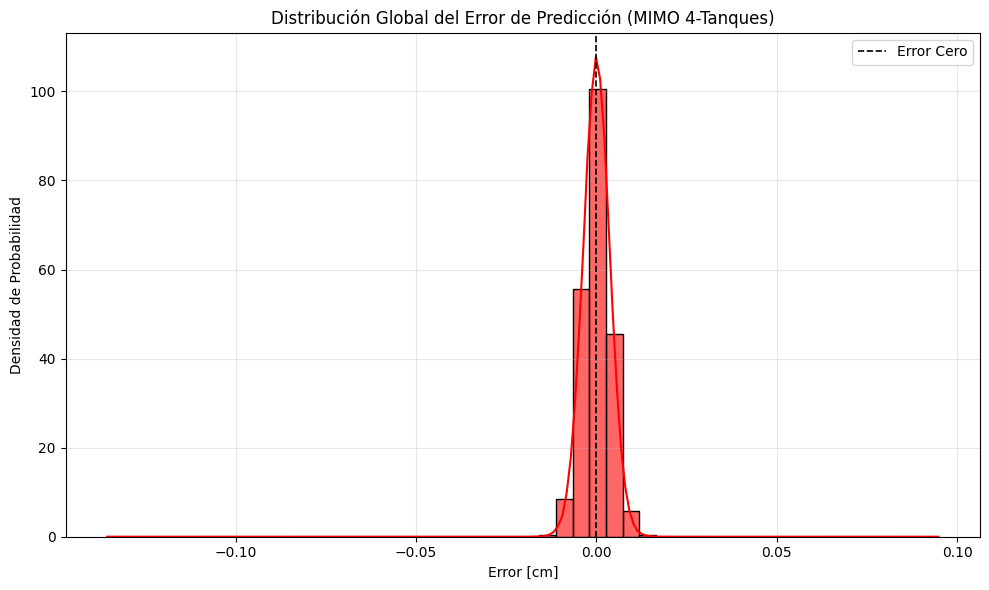

Desviación Estándar del Error: 0.003813 cm
Media del Error (Bias): 0.000002 cm


In [31]:
plt.figure(figsize=(10, 6))

# Distribución del error global (cm)
sns.histplot(error_full, kde=True, color='red', bins=50, stat="density", alpha=0.6)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2, label='Error Cero')
plt.title('Distribución Global del Error de Predicción (MIMO 4-Tanques)')
plt.xlabel('Error [cm]')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print(f"Desviación Estándar del Error: {np.std(error_full):.6f} cm")
print(f"Media del Error (Bias): {np.mean(error_full):.6f} cm")

## Predicción de horizonte de valores futuros de las alturas de los tanques

In [32]:
# Configuración del horizonte y matrices de peso
N_horizon = 25
Nc = 1
dt = 0.2
Q = np.diag([500.0, 500.0, 0.0, 0.0])
R = np.diag([0.01, 0.01])
Rd = np.diag([1.0, 1.0])

# Dimensiones del sistema
nx = 4
nu = 2
N = N_horizon

# Definición de variables simbólicas
U = ca.MX.sym('U', nu, Nc)
h0_sym = ca.MX.sym('h0', nx)
h_refs_sym = ca.MX.sym('h_refs', 4, N)
u_prev_sym = ca.MX.sym('u_prev', nu)

# Vector de parámetros para el solver
P = ca.vertcat(h0_sym, ca.reshape(h_refs_sym, -1, 1), u_prev_sym)

# Inicialización de variables de optimización
costo = 0
g_slew = []

# Extracción de pesos y sesgos desde PyTorch a CasADi
params_ca = {}
with torch.no_grad():
    linears = [m for m in model.net if isinstance(m, nn.Linear)]
    for i, layer in enumerate(linears):
        params_ca[f'W{i}'] = ca.DM(layer.weight.cpu().numpy())
        params_ca[f'b{i}'] = ca.DM(layer.bias.cpu().numpy())

# Conversión de matrices de costo a formato CasADi
Q_ca = ca.DM(Q)
R_ca = ca.DM(R)
Rd_ca = ca.DM(Rd)

# Definición de constantes de normalización para la PINN
h_min_ca = ca.vertcat(SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h2']['min'],
                      SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h4']['min'])
h_max_ca = ca.vertcat(SCALING_PARAMS['h1']['max'], SCALING_PARAMS['h2']['max'],
                      SCALING_PARAMS['h3']['max'], SCALING_PARAMS['h4']['max'])
v_min_ca = ca.vertcat(SCALING_PARAMS['v1']['min'], SCALING_PARAMS['v2']['min'])
v_max_ca = ca.vertcat(SCALING_PARAMS['v1']['max'], SCALING_PARAMS['v2']['max'])

In [33]:
# --- DEFINICIÓN SIMBÓLICA DE LA RED (PINN) EN CASADI ---

# Entrada simbólica normalizada [h1..h4, v1, v2]
x_in_sym = ca.MX.sym('x_in', 6)
x_layer = x_in_sym
num_total_layers = len([k for k in params_ca.keys() if 'W' in k])

# Reconstrucción de la arquitectura de la red con activación SiLU
for j in range(num_total_layers):
    lin_out = params_ca[f'W{j}'] @ x_layer + params_ca[f'b{j}']
    if j < (num_total_layers - 1):
        x_layer = lin_out / (1 + ca.exp(-lin_out))
    else:
        x_layer = lin_out

# Creación de la función CasADi para el paso forward
PINN_func = ca.Function('PINN_func', [x_in_sym], [x_layer])

# --- CONSTRUCCIÓN DEL HORIZONTE DE PREDICCIÓN Y COSTO ---

h_loop = h0_sym

for i in range(N):
    if i < Nc:
        u_k = U[:, i] # Variable de decisión libre
    else:
        u_k = U[:, Nc-1] # Se mantiene constante el último valor de control

    h_ref_k = h_refs_sym[:, i]

    # Normalización de variables de entrada
    h_norm = (h_loop - h_min_ca) / (h_max_ca - h_min_ca)
    u_norm = (u_k - v_min_ca) / (v_max_ca - v_min_ca)

    # Predicción del estado siguiente normalizado
    h_next_norm = PINN_func(ca.vertcat(h_norm, u_norm))

    # Denormalización del estado predicho
    h_next = h_next_norm * (h_max_ca - h_min_ca) + h_min_ca

    # Actualización de trayectoria y cálculo de error
    h_loop = h_next
    err = h_loop - h_ref_k

    # Acumulación de costos de estado y control
    costo += ca.mtimes([err.T, Q_ca, err])
    costo += ca.mtimes([u_k.T, R_ca, u_k])

    if i < Nc:
        u_prev_step = u_prev_sym if i == 0 else U[:, i-1]
        u_diff = u_k - u_prev_step
        costo += ca.mtimes([u_diff.T, Rd_ca, u_diff])
        g_slew.append(u_diff)

In [34]:
# --- CONFIGURACIÓN DEL PROBLEMA DE OPTIMIZACIÓN (NLP) ---

# Concatenación de restricciones y vector de decisión
g_total = ca.vertcat(*g_slew)
u_optim = ca.reshape(U, -1, 1)

# Estructura del problema NLP
nlp = {'x': u_optim, 'f': costo, 'g': g_total, 'p': P}

# Opciones del solver SQP para ejecución en tiempo real
opts = {
    'qpsol': 'qpoases',
    'max_iter': 1,
    'qpsol_options': {'printLevel': 'none'},
    'print_iteration': False,
    'print_header': False,
    'print_status': False,
    'print_time': False,
    'error_on_fail': False
}

# Instanciación del solver
solver = ca.nlpsol('solver', 'sqpmethod', nlp, opts)

# --- DEFINICIÓN DE LÍMITES Y RESTRICCIONES ---

# Límites de voltaje para las bombas (Variables de decisión)
lbx = np.tile([V_min, V_min], Nc)
ubx = np.tile([V_max, V_max], Nc)

# Límites para el cambio máximo de voltaje (Slew Rate)
max_delta_v = 0.5
lbg = np.tile([-max_delta_v, -max_delta_v], Nc)
ubg = np.tile([max_delta_v, max_delta_v], Nc)

print(f"Solver NMPC-PINN configurado. Dim x: {u_optim.shape}, Dim g: {g_total.shape}")


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.

Solver NMPC-PINN configurado. Dim x: (2,

In [47]:
# --- GENERADORES DE TRAYECTORIA ---

# Referencia de valor fijo
def ref_constante(t, valor=12.0):
    return valor

# Referencia con oscilación sinusoidal
def ref_sinusoidal(t, offset=12.0, amp=3.0, freq=0.01):
    return offset + amp * np.sin(2 * np.pi * freq * t)

# Referencia tipo señal cuadrada
def ref_cuadrada(t, offset=9.0, amp=2.0, freq=0.005):
    return offset + amp * np.sign(np.sin(2 * np.pi * freq * t))

# Referencia con dinámica de carga/descarga (Filtro RC)
def ref_filtro_rc(t, tau=10.0, t_cambio=50.0, v1=10.0, v2=14.0):
    ciclo = int(t / t_cambio)
    target = v2 if ciclo % 2 != 0 else v1
    t_relativo = t % t_cambio
    v_inicial = v2 if target == v1 else v1
    return target + (v_inicial - target) * np.exp(-t_relativo / tau)

# Generador de referencia por tramos (Step sequences)
def ref_escalon_secuencia(t, valores, periodo=200):
    indice = int(t / periodo) % len(valores)
    return valores[indice]

# --- SELECCIÓN DE REFERENCIAS PARA EL CONTROL ---

# Definición de señales para los tanques inferiores
referencia_h1 = lambda t: ref_escalon_secuencia(t, [12, 15, 10, 14, 16])
referencia_h2 = lambda t: ref_escalon_secuencia(t, [16, 14, 10, 15, 12])
#referencia_h1 = lambda t: ref_sinusoidal(t)
#referencia_h2 = lambda t: ref_sinusoidal(t)

In [48]:
# --- PARÁMETROS DE TIEMPO Y SIMULACIÓN ---
T_control = 1500
steps_control = int(T_control / dt)
t_test = np.linspace(0, T_control, steps_control)

# Inicialización de matriz de referencias (4 estados)
h_ref_full = np.zeros((steps_control, 4))

# Configuración de ruido para robustez (Sensores y Actuadores)
std_sensor = 0.10
std_actuador = 0.15

# Generación de perfiles de referencia para h1 y h2
for i in range(steps_control):
    t_actual = t_test[i]
    h_ref_full[i, 0] = referencia_h1(t_actual)
    h_ref_full[i, 1] = referencia_h2(t_actual)

# Nota: El solver PINN opera directamente con estados físicos [cm]

In [49]:
# --- BUCLE DE CONTROL EN LAZO CERRADO (NMPC-PINN) ---

# Inicialización de históricos y estado inicial
h_history = np.zeros((steps_control, 4))
u_history = np.zeros((steps_control, 2))
h_current = h0.copy()
u_prev_applied = np.array([3.0, 3.0])

# Almacenamiento de tiempo de iteraciones del solver
solve_times = []      
start_wall_time = time.time()

print("Iniciando NMPC basado en PINN...")
print("-" * 80)
print(f"{'Paso':<6} | {'h1 (Ref)':<15} | {'h2 (Ref)':<15} | {'V1':<8} | {'V2':<8}")

for k in range(steps_control):
    # Lectura de sensores con ruido gaussiano
    h_medido = np.maximum(h_current + std_sensor * np.random.randn(4), 0.0)

    # Definición del horizonte de referencia futura
    if k + N < steps_control:
        h_ref_horizon = h_ref_full[k : k + N].T
    else:
        pad = N - (steps_control - k)
        h_ref_horizon = np.hstack([h_ref_full[k:].T, np.tile(h_ref_full[-1:], (pad, 1)).T])

    # Construcción del vector de parámetros (Estado actual, Referencias, Control previo)
    p_val = ca.vertcat(
        h_medido,
        h_ref_horizon.flatten(order='F'),
        u_prev_applied
    )

    # Ejecución del solver NMPC con arranque en caliente (Warm Start)
    u_init = np.tile(u_prev_applied, Nc)
    t_start_iter = time.time()

    sol = solver(x0=u_init, p=p_val,
                 lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)
    
    t_end_iter = time.time()
    solve_times.append(t_end_iter - t_start_iter)
    u_init = sol['x']

    # Extracción de la acción de control óptima inmediata
    u_all_opt = np.array(sol['x']).reshape(Nc, 2)
    u_nmpc = u_all_opt[0, :]

    # Aplicación de control ruidoso a la planta real
    u_real = np.clip(u_nmpc + std_actuador * np.random.randn(2), V_min, V_max)

    # Integración de la dinámica real del sistema (Planta ODE)
    sol_ode = solve_ivp(
        lambda t, y: nonlinear_ode_system_model(t, y, lambda _: u_real,
                     A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2),
        [0, dt], h_current, t_eval=[dt]
    )

    # Actualización de estados para la siguiente iteración
    h_current = sol_ode.y[:, -1]
    u_prev_applied = u_nmpc

    # Almacenamiento de resultados
    h_history[k] = h_current
    u_history[k] = u_nmpc

    # Impresión de telemetría cada 100 pasos
    if k % 100 == 0:
        print(f"{k:<6d} | {h_current[0]:5.2f} ({h_ref_full[k,0]:5.2f}) | "
              f"{h_current[1]:5.2f} ({h_ref_full[k,1]:5.2f}) | "
              f"{u_nmpc[0]:5.2f}V | {u_nmpc[1]:5.2f}V")

print("-" * 80)
print("Simulación NMPC-PINN completada.")

# --- Cálculo de métricas finales ---
total_execution_time = time.time() - start_wall_time
total_simulated_time = steps_control * dt
rtf = total_simulated_time / total_execution_time

Iniciando NMPC basado en PINN...
--------------------------------------------------------------------------------
Paso   | h1 (Ref)        | h2 (Ref)        | V1       | V2      
0      | 12.39 (12.00) | 12.71 (16.00) |  2.50V |  3.50V
100    | 12.02 (12.00) | 15.85 (16.00) |  1.98V |  6.00V
200    | 12.03 (12.00) | 15.87 (16.00) |  2.02V |  4.45V
300    | 11.99 (12.00) | 15.97 (16.00) |  1.77V |  3.69V
400    | 12.01 (12.00) | 15.98 (16.00) |  2.54V |  2.51V
500    | 11.97 (12.00) | 15.91 (16.00) |  2.72V |  4.80V
600    | 11.99 (12.00) | 16.08 (16.00) |  2.33V |  2.92V
700    | 11.93 (12.00) | 15.92 (16.00) |  2.96V |  5.40V
800    | 12.06 (12.00) | 15.98 (16.00) |  2.87V |  4.07V
900    | 12.02 (12.00) | 16.03 (16.00) |  2.61V |  4.30V
1000   | 13.12 (15.00) | 15.03 (14.00) |  6.00V |  0.00V
1100   | 14.96 (15.00) | 13.88 (14.00) |  2.41V |  2.74V
1200   | 15.00 (15.00) | 14.00 (14.00) |  4.73V |  2.25V
1300   | 15.00 (15.00) | 14.01 (14.00) |  2.81V |  3.75V
1400   | 14.97 (15.00) 

In [50]:
print("\n" + "="*30)
print(" METRICAS DE RENDIMIENTO")
print("="*30)

# 1. Tiempo total de ejecución (Wall-clock time)
print(f"Tiempo total de cómputo:    {total_execution_time:.4f} s")

# 2. Tiempo promedio por iteración del solver
avg_solve_time = np.mean(solve_times)
print(f"Promedio por iteración:     {avg_solve_time*1000:.2f} ms")

# 3. Tiempo de simulación física total
print(f"Tiempo simulado (físico):   {total_simulated_time:.2f} s")

# 4. Real-Time Factor (RTF)
print(f"Real-Time Factor (RTF):     {rtf:.2f}x")

if rtf > 1:
    print(f"\nEstado: El controlador es {rtf:.1f} veces más rápido que el proceso real.")
else:
    print(f"\nEstado: ALERTA - El controlador es más lento que el proceso real.")

print("="*30)


 METRICAS DE RENDIMIENTO
Tiempo total de cómputo:    170.2420 s
Promedio por iteración:     21.76 ms
Tiempo simulado (físico):   1500.00 s
Real-Time Factor (RTF):     8.81x

Estado: El controlador es 8.8 veces más rápido que el proceso real.


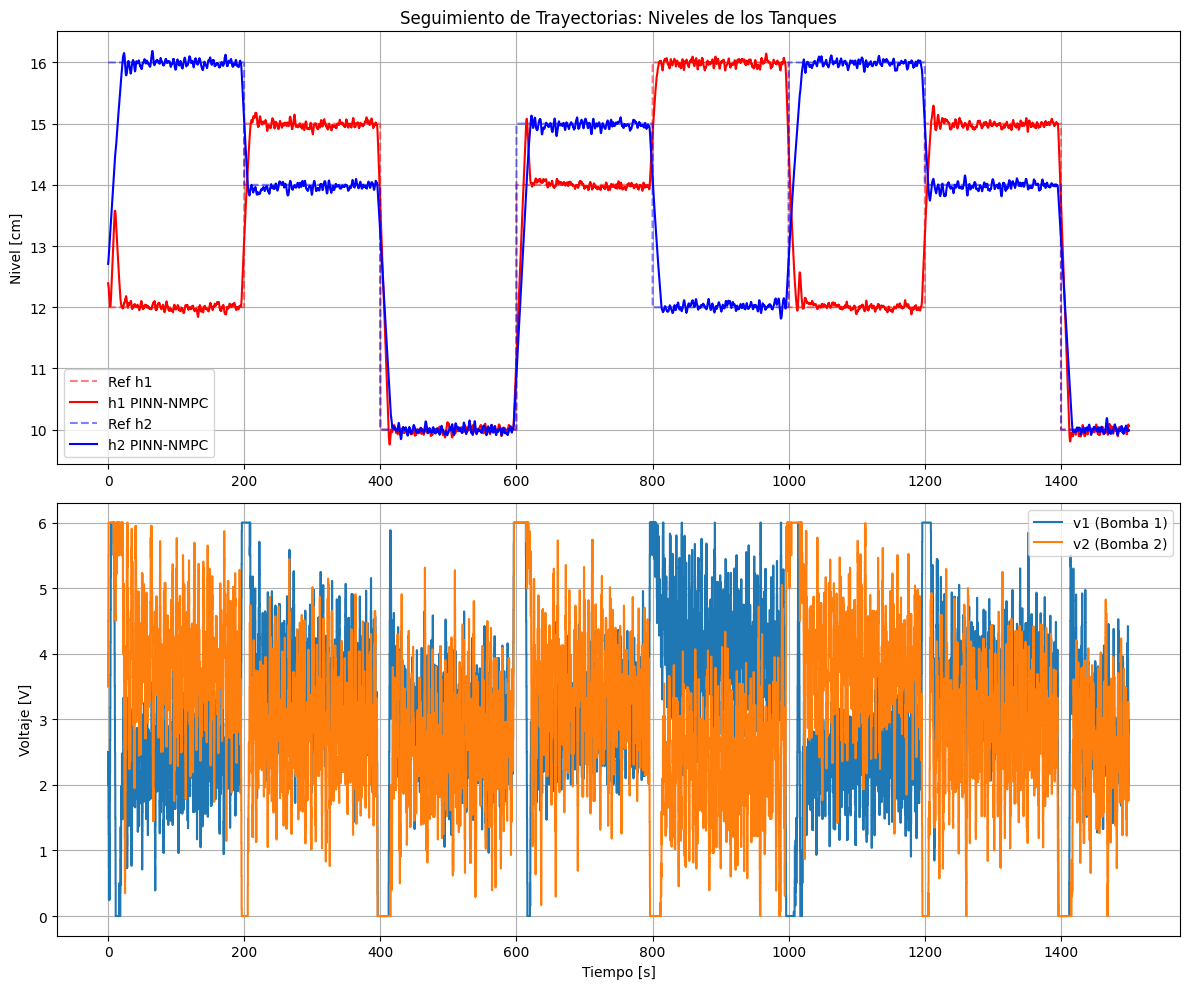

In [51]:
25# --- VISUALIZACIÓN DE RESULTADOS (TRACKING Y CONTROL) ---

plt.figure(figsize=(12, 10))

# Comparativa de niveles: Referencia vs. Respuesta real
plt.subplot(2, 1, 1)
plt.plot(t_test, h_ref_full[:, 0], 'r--', alpha=0.5, label='Ref h1')
plt.plot(t_test, h_history[:, 0], 'r', label='h1 PINN-NMPC')
plt.plot(t_test, h_ref_full[:, 1], 'b--', alpha=0.5, label='Ref h2')
plt.plot(t_test, h_history[:, 1], 'b', label='h2 PINN-NMPC')
plt.title('Seguimiento de Trayectorias: Niveles de los Tanques')
plt.ylabel('Nivel [cm]')
plt.legend()
plt.grid(True)

# Esfuerzo de control: Voltaje aplicado a las bombas
plt.subplot(2, 1, 2)
plt.step(t_test[:], u_history[:, 0], label='v1 (Bomba 1)')
plt.step(t_test[:], u_history[:, 1], label='v2 (Bomba 2)')
plt.ylabel('Voltaje [V]')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

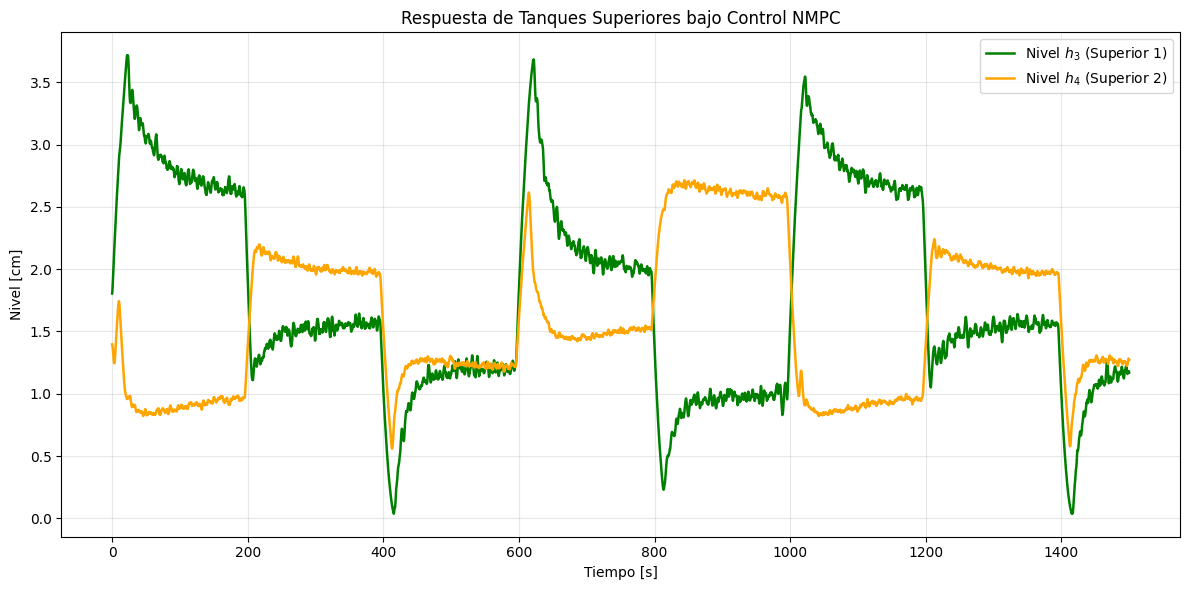

In [52]:
# --- VISUALIZACIÓN DE DINÁMICA DE TANQUES SUPERIORES ---
plt.figure(figsize=(12, 6))

# Trayectoria de h3 y h4 (Tanques de descarga superior)
plt.plot(t_test, h_history[:, 2], 'g', linewidth=1.8, label='Nivel $h_3$ (Superior 1)')
plt.plot(t_test, h_history[:, 3], 'orange', linewidth=1.8, label='Nivel $h_4$ (Superior 2)')

plt.title('Respuesta de Tanques Superiores bajo Control NMPC')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# --- CÁLCULO DE MÉTRICAS DE CONTROL: EVALUACIÓN PINN-NMPC ---

def calculate_control_metrics(real, ref):
    error = real - ref
    sse = np.sum(error**2)
    rmse = np.sqrt(np.mean(error**2))

    # NRMSE normalizado por el rango dinámico de la referencia
    range_ref = np.max(ref) - np.min(ref)
    nrmse = rmse / range_ref if range_ref != 0 else rmse

    return sse, rmse, nrmse

# 1. Análisis por canal (Tanques de seguimiento h1 y h2)
sse1, rmse1, nrmse1 = calculate_control_metrics(h_history[:, 0], h_ref_full[:, 0])
sse2, rmse2, nrmse2 = calculate_control_metrics(h_history[:, 1], h_ref_full[:, 1])

# 2. Análisis global del desempeño MIMO (Estados controlados)
h_real_controlled = h_history[:, :2].flatten()
h_ref_controlled = h_ref_full[:, :2].flatten()

sse_global, rmse_global, nrmse_global = calculate_control_metrics(h_real_controlled, h_ref_controlled)

# --- REPORTE DE PRECISIÓN DEL CONTROLADOR ---
print("\n" + "="*75)
print(f"{'MÉTRICA DE DESEMPEÑO':<25} | {'TANQUE 1':<12} | {'TANQUE 2':<12} | {'GLOBAL':<12}")
print("-" * 75)
print(f"{'SSE (Suma de Errores)':<25} | {sse1:12.2f} | {sse2:12.2f} | {sse_global:12.2f}")
print(f"{'RMSE (Precisión cm)':<25} | {rmse1:12.4f} | {rmse2:12.4f} | {rmse_global:12.4f}")
print(f"{'NRMSE (Error Relativo)':<25} | {nrmse1:12.4f} | {nrmse2:12.4f} | {nrmse_global:12.4f}")
print("="*75 + "\n")


MÉTRICA DE DESEMPEÑO      | TANQUE 1     | TANQUE 2     | GLOBAL      
---------------------------------------------------------------------------
SSE (Suma de Errores)     |      1126.10 |      1965.28 |      3091.39
RMSE (Precisión cm)       |       0.3875 |       0.5119 |       0.4540
NRMSE (Error Relativo)    |       0.0646 |       0.0853 |       0.0757



Error medio PINN h1: 0.0100 cm
Error medio PINN h2: 0.0090 cm


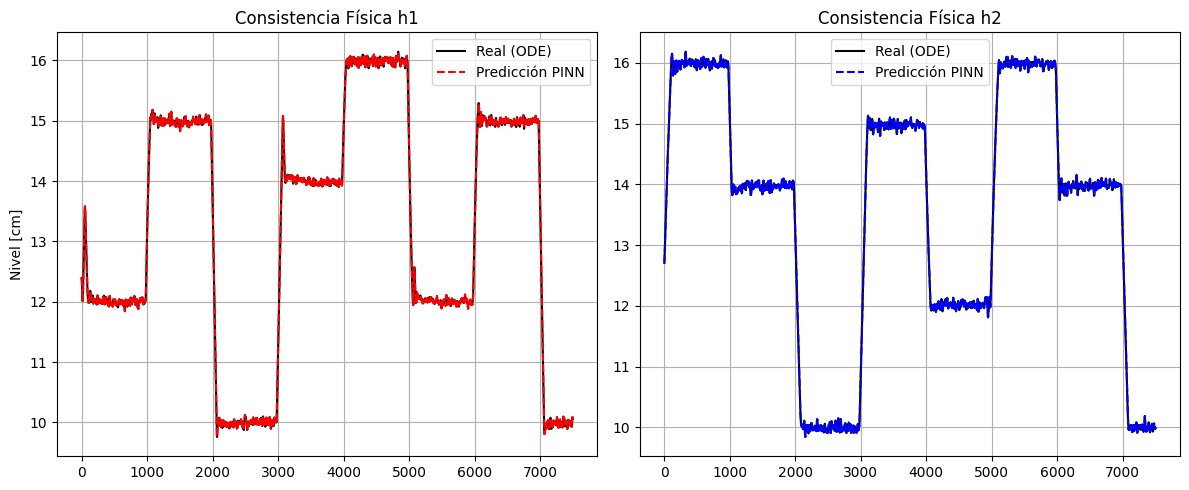

In [59]:
# --- VERIFICACIÓN DE CONSISTENCIA: MODELO PINN VS SISTEMA REAL ---

n_val = steps_control
h_real_seg = h_history[:n_val]
u_seg = u_history[:n_val]

# Predicción en lazo abierto (Open Loop) usando la PINN identificada
h_pinn_val = np.zeros((n_val, 4))
h_loop = h_history[0]

for k in range(n_val):
    h_pinn_val[k] = h_loop # Para graficar

    if k < n_val - 1:
        h_actual = h_real_seg[k] 
        u_k = u_seg[k]

        # Normalización
        h_norm = (h_actual - h_min_ca.full().flatten()) / (h_max_ca.full().flatten() - h_min_ca.full().flatten())
        u_norm = (u_k - v_min_ca.full().flatten()) / (v_max_ca.full().flatten() - v_min_ca.full().flatten())

        # Predicción
        h_next_norm = PINN_func(ca.vertcat(h_norm, u_norm))

        # Denormalización (este será el punto en la gráfica para k+1)
        h_loop = np.array(h_next_norm).flatten() * (h_max_ca.full().flatten() - h_min_ca.full().flatten()) + h_min_ca.full().flatten()

# Evaluación cuantitativa del error de modelado (MAE)
mae_h1_pinn = np.mean(np.abs(h_real_seg[:, 0] - h_pinn_val[:, 0]))
mae_h2_pinn = np.mean(np.abs(h_real_seg[:, 1] - h_pinn_val[:, 1]))

print(f"Error medio PINN h1: {mae_h1_pinn:.4f} cm")
print(f"Error medio PINN h2: {mae_h2_pinn:.4f} cm")

# --- GRÁFICAS DE VALIDACIÓN DE FIDELIDAD DEL MODELO NEURONAL ---
plt.figure(figsize=(12, 5))

# Comparativa de trayectorias para el Tanque 1
plt.subplot(1, 2, 1)
plt.plot(h_real_seg[:, 0], 'k', label='Real (ODE)')
plt.plot(h_pinn_val[:, 0], 'r--', label='Predicción PINN')
plt.title('Consistencia Física h1')
plt.ylabel('Nivel [cm]')
plt.legend()
plt.grid(True)

# Comparativa de trayectorias para el Tanque 2
plt.subplot(1, 2, 2)
plt.plot(h_real_seg[:, 1], 'k', label='Real (ODE)')
plt.plot(h_pinn_val[:, 1], 'b--', label='Predicción PINN')
plt.title('Consistencia Física h2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Error medio h3 (PINN): 0.0068 cm
Error medio h4 (PINN): 0.0042 cm


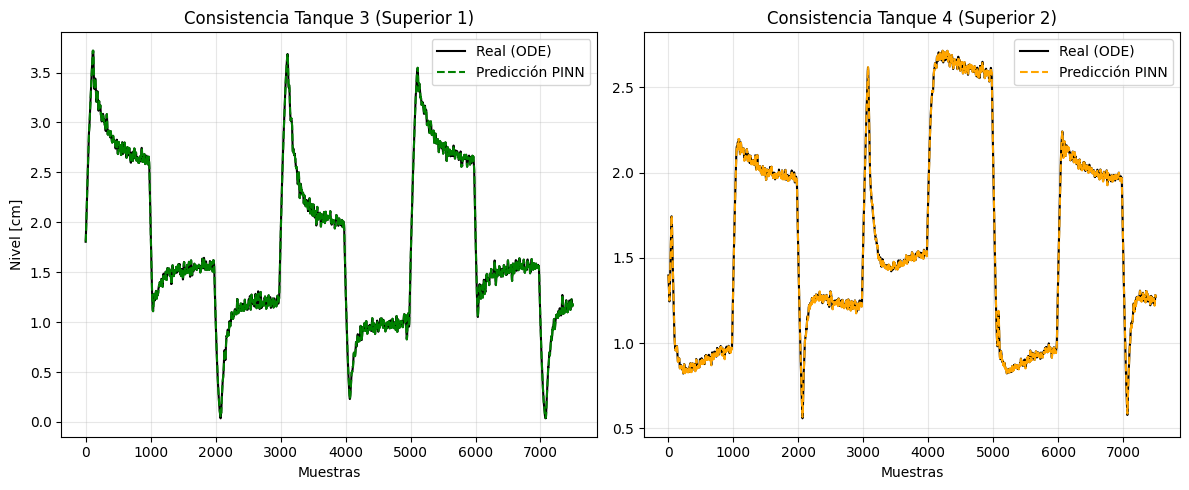

In [60]:
# --- VERIFICACIÓN DE CONSISTENCIA: TANQUES SUPERIORES (h3 y h4) ---

# Evaluación cuantitativa del error de modelado para tanques superiores (MAE)
mae_h3_pinn = np.mean(np.abs(h_real_seg[:, 2] - h_pinn_val[:, 2]))
mae_h4_pinn = np.mean(np.abs(h_real_seg[:, 3] - h_pinn_val[:, 3]))

print(f"Error medio h3 (PINN): {mae_h3_pinn:.4f} cm")
print(f"Error medio h4 (PINN): {mae_h4_pinn:.4f} cm")

# Gráficas de validación para niveles superiores
plt.figure(figsize=(12, 5))

# Comparativa de trayectorias para el Tanque 3
plt.subplot(1, 2, 1)
plt.plot(h_real_seg[:, 2], 'k', label='Real (ODE)')
plt.plot(h_pinn_val[:, 2], 'g--', label='Predicción PINN')
plt.title('Consistencia Tanque 3 (Superior 1)')
plt.ylabel('Nivel [cm]')
plt.xlabel('Muestras')
plt.legend()
plt.grid(True, alpha=0.3)

# Comparativa de trayectorias para el Tanque 4
plt.subplot(1, 2, 2)
plt.plot(h_real_seg[:, 3], 'k', label='Real (ODE)')
plt.plot(h_pinn_val[:, 3], 'orange', linestyle='--', label='Predicción PINN')
plt.title('Consistencia Tanque 4 (Superior 2)')
plt.xlabel('Muestras')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

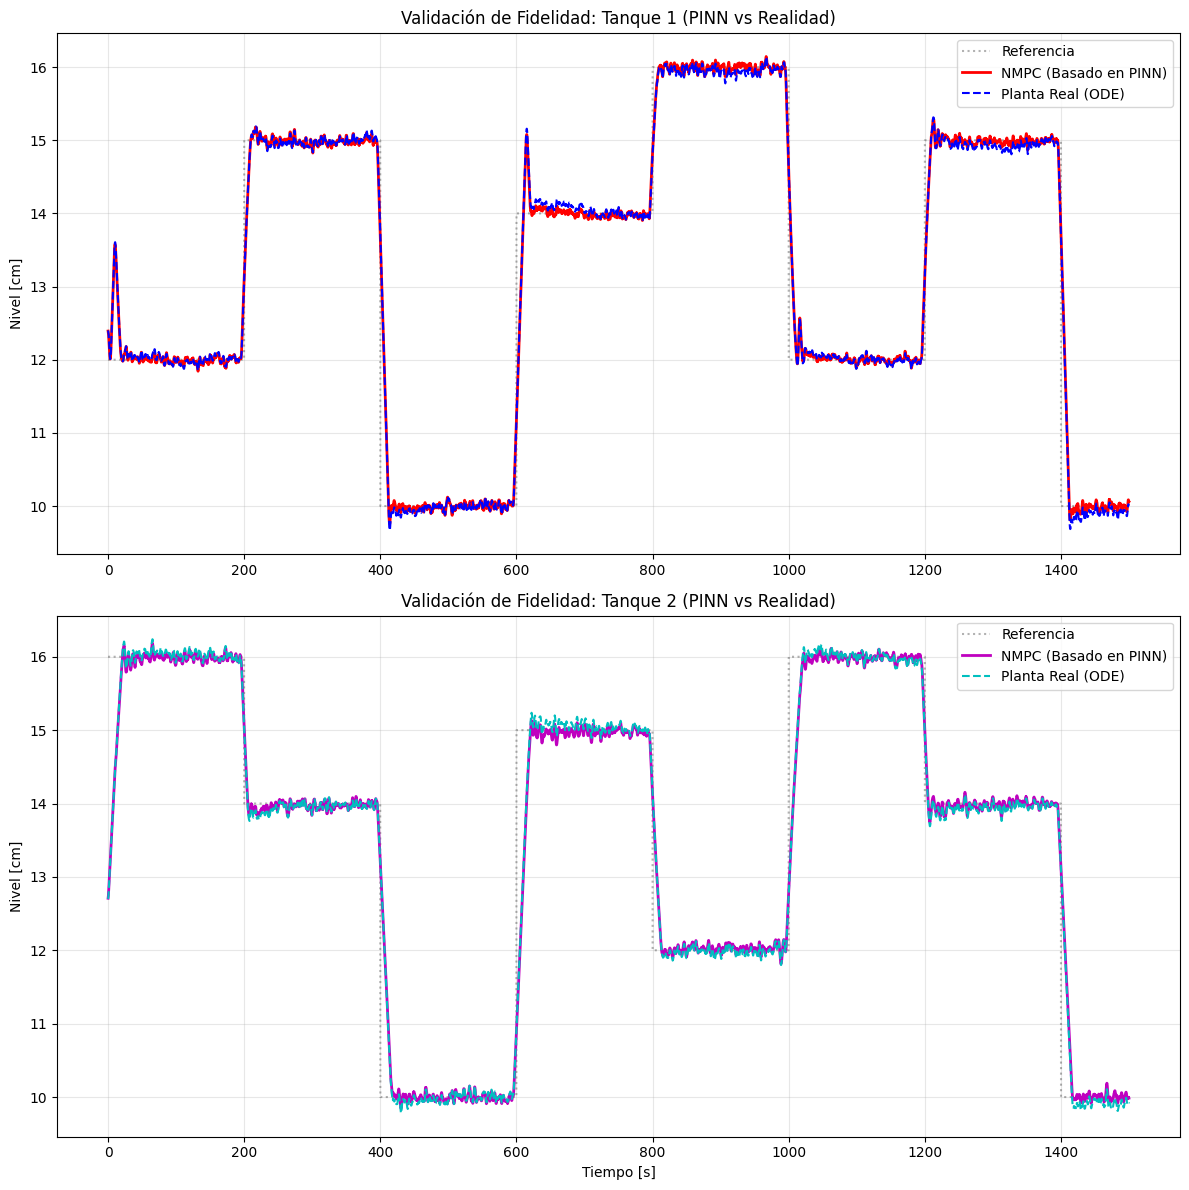

Discrepancia promedio PINN vs Real en h1: 0.03256 cm
Discrepancia promedio PINN vs Real en h2: 0.03874 cm


In [61]:
# --- VALIDACIÓN DE FIDELIDAD: PINN-NMPC VS PLANTA REAL ---

# Interpolación de voltajes calculados para integración continua
u_pinn_fun = interp1d(t_test, u_history, axis=0, kind='linear', fill_value='extrapolate')

# Wrapper del modelo no lineal real alimentado por el control de la PINN
ode_pinn_validation_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_pinn_fun,
    A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2
)

# Simulación de la planta física real bajo la secuencia de control óptima
sol_pinn_validation = solve_ivp(
    fun=ode_pinn_validation_wrapper,
    t_span=[t_test[0], t_test[-1]],
    y0=h0,
    method='RK45',
    t_eval=t_test,
    rtol=1e-7,
    atol=1e-9
)
h_real_validation = sol_pinn_validation.y.T

# --- VISUALIZACIÓN DE DISCREPANCIA MODELO-PLANTA ---
plt.figure(figsize=(12, 12))

# Comparativa de fidelidad para el Tanque 1 (Inferior)
plt.subplot(2, 1, 1)
plt.plot(t_test, h_ref_full[:, 0], 'k:', alpha=0.3, label='Referencia')
plt.plot(t_test, h_history[:, 0], 'r', linewidth=2, label='NMPC (Basado en PINN)')
plt.plot(t_test, h_real_validation[:, 0], 'b--', linewidth=1.5, label='Planta Real (ODE)')
plt.title('Validación de Fidelidad: Tanque 1 (PINN vs Realidad)')
plt.ylabel('Nivel [cm]')
plt.legend()
plt.grid(True, alpha=0.3)

# Comparativa de fidelidad para el Tanque 2 (Inferior)
plt.subplot(2, 1, 2)
plt.plot(t_test, h_ref_full[:, 1], 'k:', alpha=0.3, label='Referencia')
plt.plot(t_test, h_history[:, 1], 'm', linewidth=2, label='NMPC (Basado en PINN)')
plt.plot(t_test, h_real_validation[:, 1], 'c--', linewidth=1.5, label='Planta Real (ODE)')
plt.title('Validación de Fidelidad: Tanque 2 (PINN vs Realidad)')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cuantificación de la discrepancia (Error de modelado en lazo cerrado)
discrepancia_h1 = np.mean(np.abs(h_history[:, 0] - h_real_validation[:, 0]))
discrepancia_h2 = np.mean(np.abs(h_history[:, 1] - h_real_validation[:, 1]))

print(f"Discrepancia promedio PINN vs Real en h1: {discrepancia_h1:.5f} cm")
print(f"Discrepancia promedio PINN vs Real en h2: {discrepancia_h2:.5f} cm")

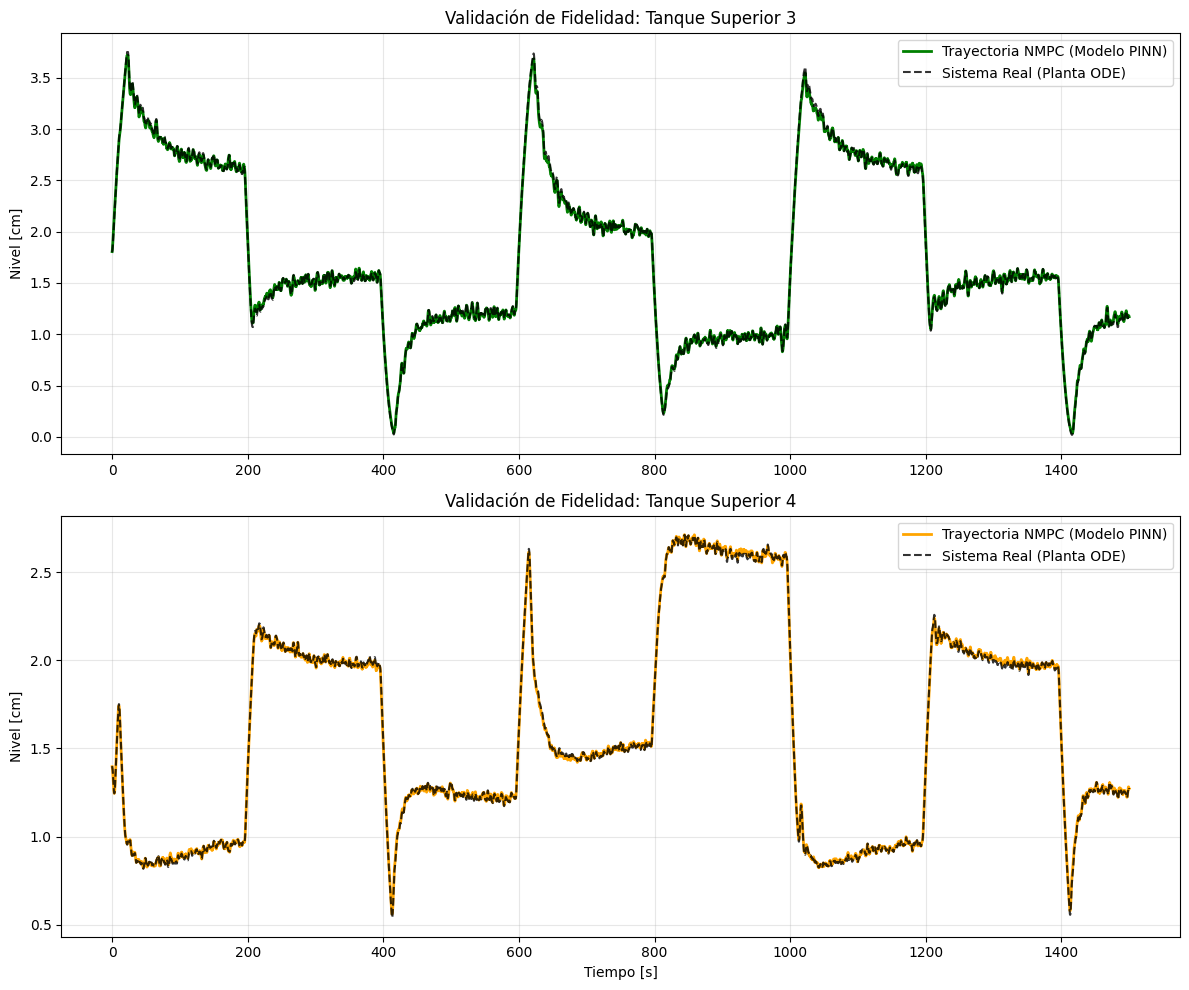

Discrepancia promedio PINN vs Real en h3: 0.01239 cm
Discrepancia promedio PINN vs Real en h4: 0.00694 cm


In [62]:
# --- VALIDACIÓN DE FIDELIDAD: TANQUES SUPERIORES (h3 y h4) ---

plt.figure(figsize=(12, 10))

# Análisis de fidelidad para el Tanque 3 (Superior 1)
plt.subplot(2, 1, 1)
# Trayectoria registrada por el NMPC basada en la predicción de la PINN
plt.plot(t_test, h_history[:, 2], 'g', linewidth=2, label='Trayectoria NMPC (Modelo PINN)')
# Trayectoria de la planta real (ODE) bajo el mismo perfil de control
plt.plot(t_test, h_real_validation[:, 2], 'k--', linewidth=1.5, alpha=0.8, label='Sistema Real (Planta ODE)')
plt.title('Validación de Fidelidad: Tanque Superior 3')
plt.ylabel('Nivel [cm]')
plt.legend()
plt.grid(True, alpha=0.3)

# Análisis de fidelidad para el Tanque 4 (Superior 2)
plt.subplot(2, 1, 2)
plt.plot(t_test, h_history[:, 3], 'orange', linewidth=2, label='Trayectoria NMPC (Modelo PINN)')
plt.plot(t_test, h_real_validation[:, 3], 'k--', linewidth=1.5, alpha=0.8, label='Sistema Real (Planta ODE)')
plt.title('Validación de Fidelidad: Tanque Superior 4')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cálculo de la discrepancia (Error de predicción en lazo cerrado para estados superiores)
discrepancia_h3 = np.mean(np.abs(h_history[:, 2] - h_real_validation[:, 2]))
discrepancia_h4 = np.mean(np.abs(h_history[:, 3] - h_real_validation[:, 3]))

print(f"Discrepancia promedio PINN vs Real en h3: {discrepancia_h3:.5f} cm")
print(f"Discrepancia promedio PINN vs Real en h4: {discrepancia_h4:.5f} cm")